In [77]:
# filepath: /Users/jennifermajer/Documents/CUNY/EPID 825/Project/maternal_depression.ipynb
# Kernal: r-reticulate (Python 3.10.14)


# Imports
%pip install xgboost scikeras tensorflow shap pandas matplotlib seaborn scikit-learn imblearn pdpbox scikit-optimize ipywidgets tabulate
# Required imports for oversampling
from imblearn.over_sampling import SMOTE
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import shap


class CustomKerasClassifier(KerasClassifier):
    def __sklearn_tags__(self):
        return {"estimator_type": "classifier"}

# Set working directory
os.chdir("/Users/jennifermajer/Documents/CUNY/EPID 825/Project")

## Load data 
# Wide data - not imputed
dat_ml_6m = pd.read_csv ("dat_ml_6m.csv")
dat_ml_1y = pd.read_csv("dat_ml_1y.csv")
dat_ml_7y = pd.read_csv("dat_ml_7y.csv")
dat_ml_7y_dep = pd.read_csv("dat_ml_7y_dep.csv")
dat_ml_7y_never = pd.read_csv("dat_ml_7y_never.csv")


# Wide data - imputation using mice from R
complete_data_6m = pd.read_csv("complete_data_mice_6m.csv")
complete_data_1y = pd.read_csv("complete_data_mice_1y.csv")
complete_data_7y = pd.read_csv("complete_data_mice_7y.csv")
complete_data_7y_dep = pd.read_csv("complete_data_mice_7y_dep.csv")
complete_data_7y_never = pd.read_csv("complete_data_mice_7y_never.csv")


Note: you may need to restart the kernel to use updated packages.


In [55]:
# Assess data

## 6 months
print(complete_data_6m.info())
print(dat_ml_6m.info())


## 1 year
print(complete_data_1y.info())
print(dat_ml_1y.info())


## 7 years
print(complete_data_7y.info())

print(dat_ml_7y.info())

print(complete_data_7y_dep.info())

print(complete_data_7y_never.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   treat                     818 non-null    int64  
 1   newid                     818 non-null    int64  
 2   uc                        818 non-null    int64  
 3   interviewer               818 non-null    int64  
 4   month_int                 818 non-null    int64  
 5   remission_6mo             818 non-null    int64  
 6   depindex_0                818 non-null    float64
 7   depindex_0_f              818 non-null    float64
 8   mo_ht_baseline            818 non-null    float64
 9   mo_bmi_baseline           818 non-null    float64
 10  hamd_baseline             818 non-null    int64  
 11  bdq_baseline              818 non-null    int64  
 12  gaf_baseline              818 non-null    int64  
 13  ses_baseline              818 non-null    int64  
 14  age_baseli

In [81]:
# Imputation
#%pip install miceforest
import os
# Ensure libomp is found
# Ensure libomp is installed and properly linked
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'
os.environ['OMP_NUM_THREADS'] = '1'  # Limit threads to avoid conflicts
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # Avoid conflicts with OpenMP
import miceforest as mf

# Function to perform imputation and return/save imputed dataset
def impute_and_save(filepath, output_dir="imputed_data", iterations=5, seed=500):
    df = pd.read_csv(filepath)
    kernel = mf.ImputationKernel(df, random_state=seed)
    kernel.mice(iterations=iterations, n_jobs=-1)
    imputed_df = kernel.complete_data(dataset=0)

    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(filepath).replace(".csv", "_imputed.csv")
    imputed_path = os.path.join(output_dir, filename)
    imputed_df.to_csv(imputed_path, index=False)

    return imputed_df

# Define file paths
filepaths = {
    "dat_ml_6m": "dat_ml_6m.csv",
    "dat_ml_1y": "dat_ml_1y.csv",
    "dat_ml_7y": "dat_ml_7y.csv",
    "dat_ml_7y_dep": "dat_ml_7y_dep.csv",
    "dat_ml_7y_never": "dat_ml_7y_never.csv"
}

# Run imputation, save, and store in a dictionary
imputed_datasets = {}
for name, path in filepaths.items():
    print(f"Imputing and saving {name}...")
    imputed_datasets[name] = impute_and_save(path)

# Now each imputed dataset is available in memory
# Example: access 6-month dataset
dat_ml_6m_imputed = imputed_datasets["dat_ml_6m"]


Imputing and saving dat_ml_6m...
Imputing and saving dat_ml_1y...
Imputing and saving dat_ml_7y...
Imputing and saving dat_ml_7y_dep...
Imputing and saving dat_ml_7y_never...


2025-07-26 18:36:19,211 - INFO - Data loaded: (818, 47)
2025-07-26 18:36:19,229 - INFO - Data validation passed. Shape: (818, 47)
2025-07-26 18:36:19,253 - INFO - Target counts:
remission_6mo
1    489
0    329
Name: count, dtype: int64
2025-07-26 18:36:19,267 - INFO - Missing values: 0
2025-07-26 18:36:19,280 - INFO - Train=654, Hold-out=164
2025-07-26 18:36:19,290 - INFO - → Nested CV: Logistic Regression
2025-07-26 18:36:19,293 - INFO - Processing outer fold 1/5
2025-07-26 18:36:19,295 - INFO - Fold 1 treatment distribution: {1: 271, 0: 252}
2025-07-26 18:36:19,296 - INFO - Fold 1 class distribution: {1: 313, 0: 210}
2025-07-26 18:36:22,712 - INFO - Fold 1: Treatment variable selected! (F-score=83.471, rank=1)
2025-07-26 18:36:22,717 - INFO - Fold 1 AUC: 0.690
2025-07-26 18:36:22,717 - INFO - Processing outer fold 2/5
2025-07-26 18:36:22,721 - INFO - Fold 2 treatment distribution: {0: 262, 1: 261}
2025-07-26 18:36:22,721 - INFO - Fold 2 class distribution: {1: 313, 0: 210}
2025-07-26


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.671 |       0.747 |    0.68  |      0.712 | 0.717 |         0.214 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.662 |       0.756 |    0.642 |      0.694 | 0.724 |         0.214 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.676 |       0.732 |    

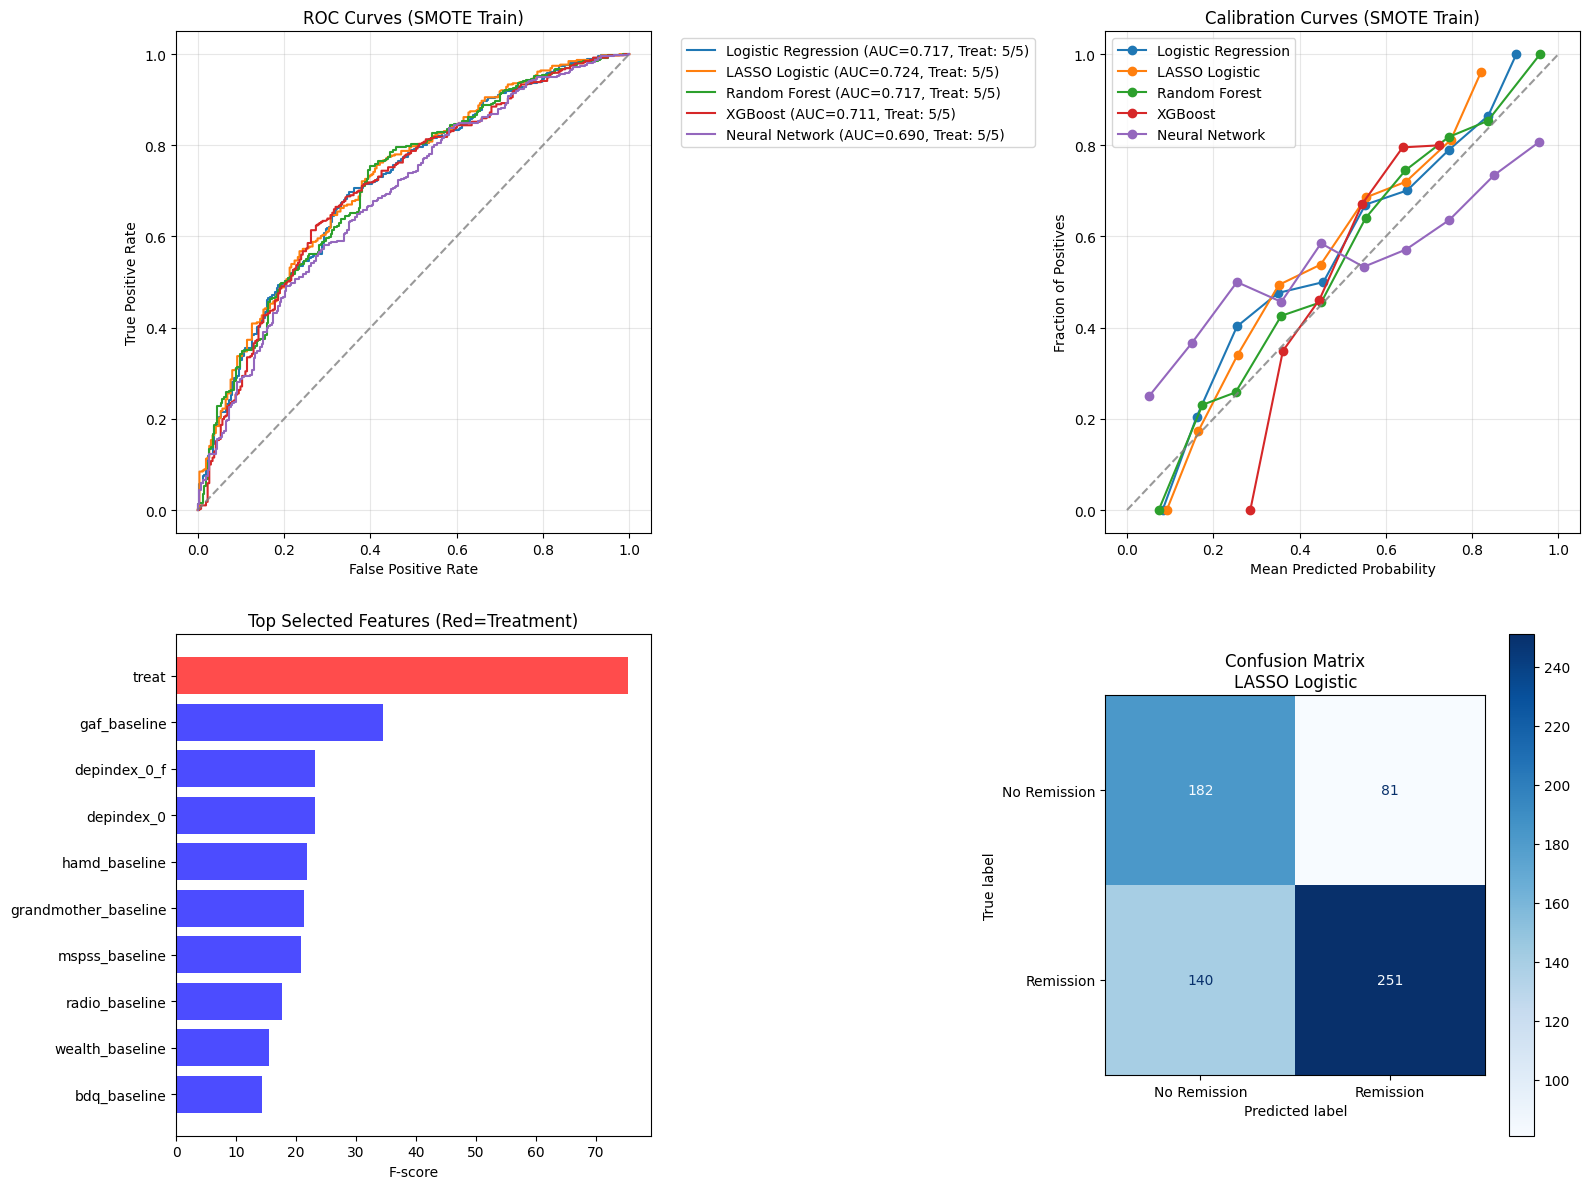

2025-07-26 18:38:31,117 - INFO - Refitted best: LASSO Logistic
2025-07-26 18:38:31,176 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.734, F1=0.720
Calibrated:   AUC=0.736, F1=0.720


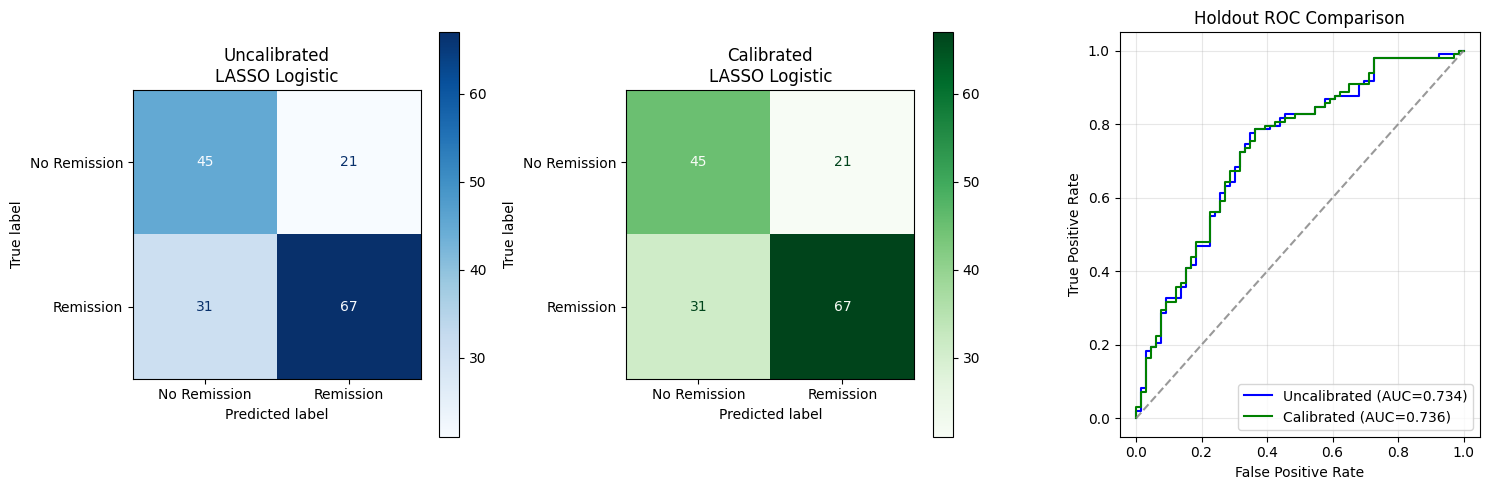

2025-07-26 18:38:31,551 - INFO - Performing SHAP analysis...
2025-07-26 18:38:31,553 - INFO - Treatment variable selected for SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.683        0.683       
Precision       0.761        0.761       
Recall          0.684        0.684       
F1 Score        0.720        0.720       
AUC             0.734        0.736       
Specificity     0.682        0.682       
Sensitivity     0.684        0.684       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  67           67          
False Positives 21           21          
True Negatives  45           45          
False Negatives 31           31          


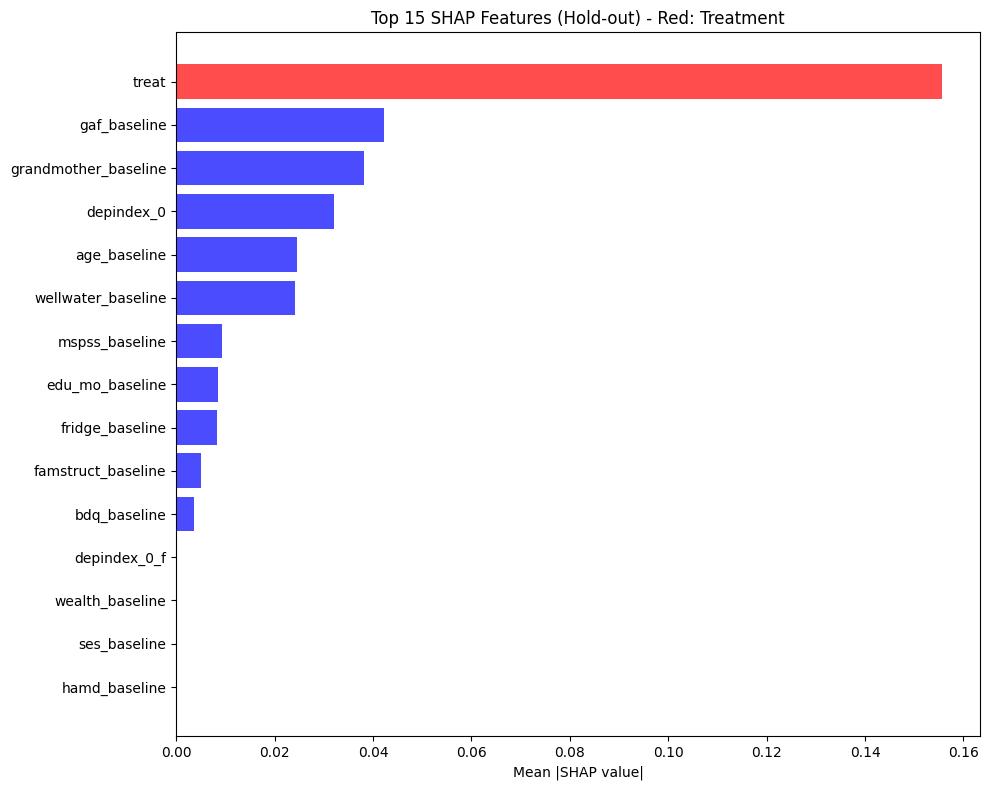

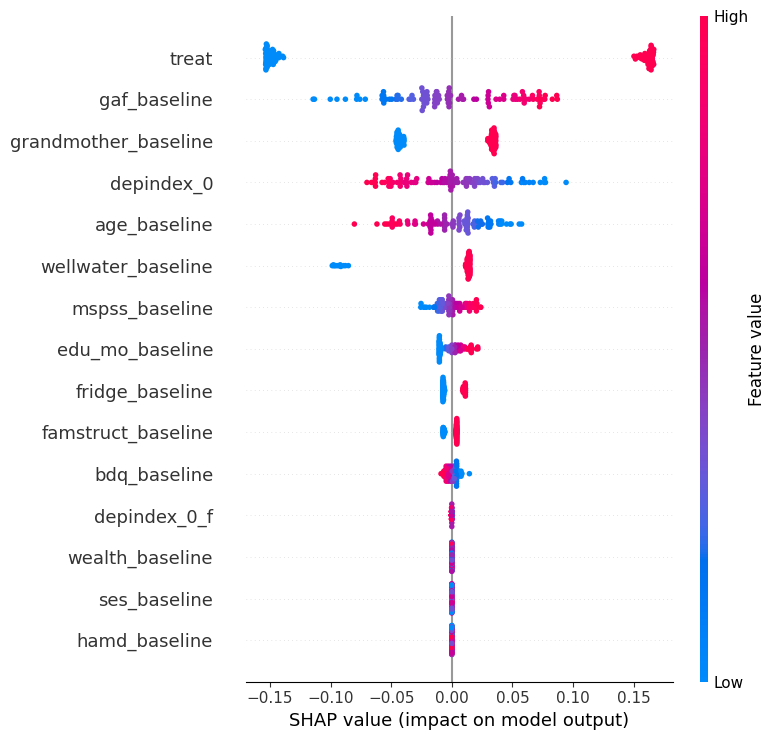


Generating SHAP Personas…
Top 3 SHAP features: ['grandmother_baseline', 'gaf_baseline', 'treat']

Top-3 SHAP Personas:
                                                   Profile  P(remission)
   grandmother_baseline=low & gaf_baseline=low & treat=low         0.271
  grandmother_baseline=low & gaf_baseline=low & treat=high         0.551
  grandmother_baseline=low & gaf_baseline=high & treat=low         0.431
 grandmother_baseline=low & gaf_baseline=high & treat=high         0.715
  grandmother_baseline=high & gaf_baseline=low & treat=low         0.335
 grandmother_baseline=high & gaf_baseline=low & treat=high         0.625
 grandmother_baseline=high & gaf_baseline=high & treat=low         0.507
grandmother_baseline=high & gaf_baseline=high & treat=high         0.774


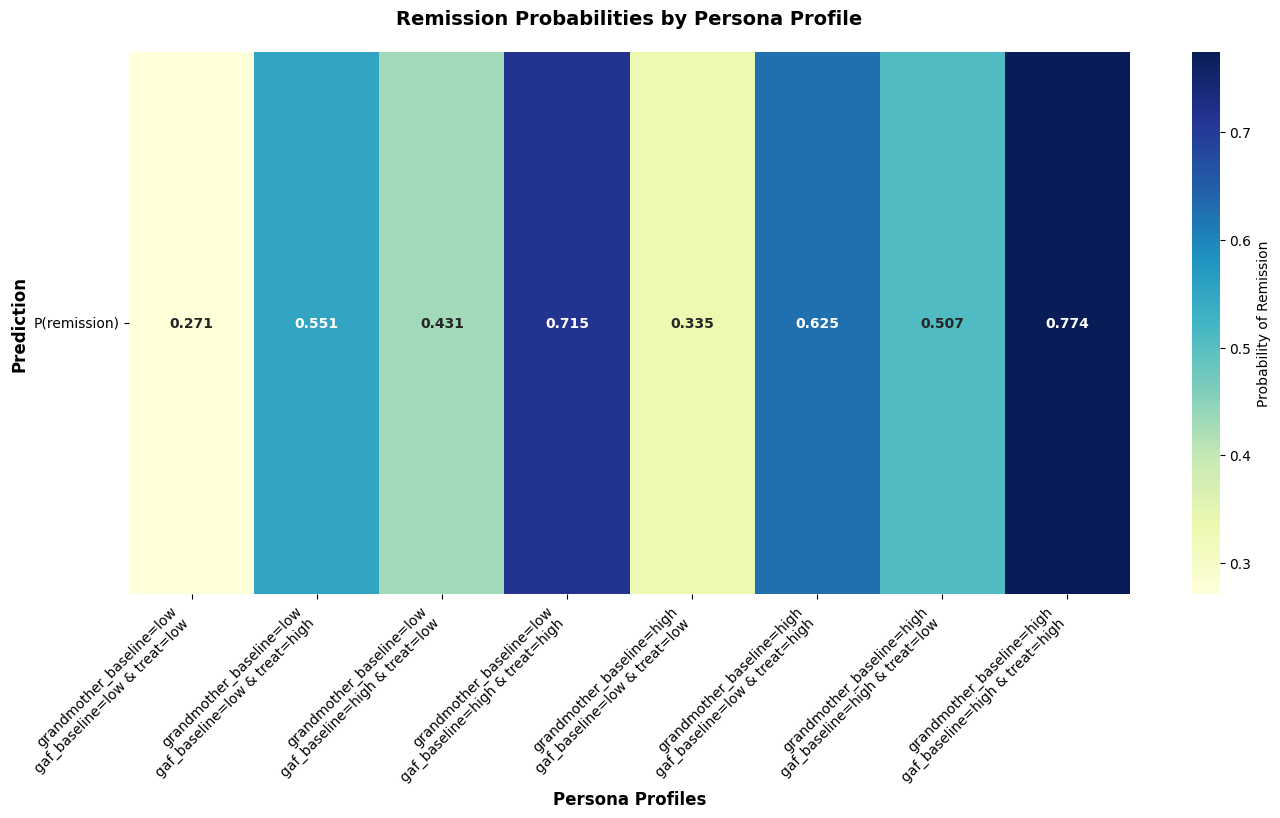

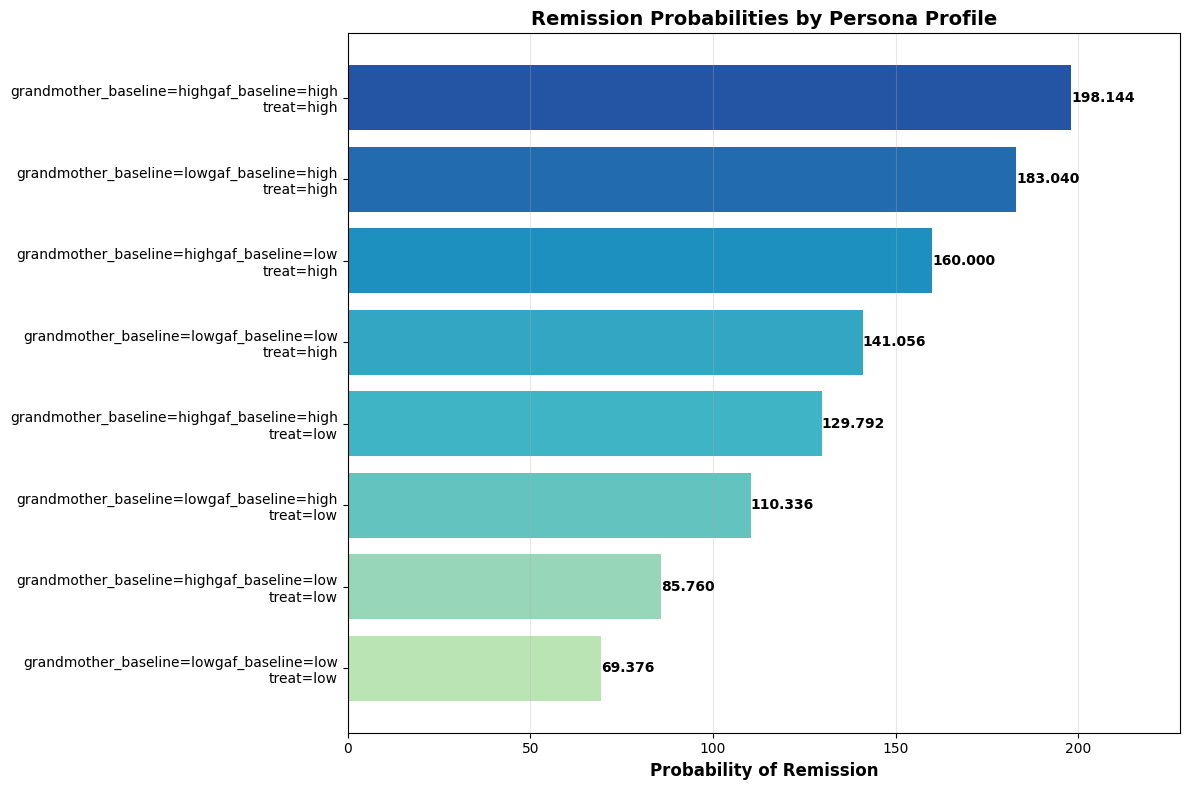


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
LASSO Logistic:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
Random Forest:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
XGBoost:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0
Neural Network:
  Treatment selected: 5/5 folds
  Average F-score: 76.581
  Average rank: 1.0

FINAL RESULTS SUMMARY
Best Model: LASSO Logistic
Hold-out Performance (Calibrated):
  Accuracy: 0.683
  Precision: 0.761
  Recall: 0.684
  F1 Score: 0.720
  AUC: 0.736
  Brier Score: 0.207
  True Negatives: 45.000
  False Positives: 21.000
  False Negatives: 31.000
  True Positives: 67.000
  Specificity: 0.682
  Sensitivity: 0.684
✓ Treatment variable was selected by the best model
Overall treatment selection rate: 25/25 (100.0%)


In [103]:
# Remission at 6 months - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "remission_6mo"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["remission_6mo"]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Remission', 'Remission'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Remission', 'Remission'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Remission', 'Remission'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_6m.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(remission)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(remission)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Remission'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Remission Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(remission)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(remission)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(remission)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(remission)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Remission', fontsize=12, fontweight='bold')
                    plt.title('Remission Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(remission)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-26 18:05:35,906 - INFO - Data loaded: (818, 47)
2025-07-26 18:05:35,910 - INFO - Data validation passed. Shape: (818, 47)
2025-07-26 18:05:35,911 - INFO - Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]
2025-07-26 18:05:35,916 - INFO - Target distribution: {1: 489, 0: 329}
2025-07-26 18:05:35,918 - INFO - Target counts:
remission_6mo
1    489
0    329
Name: count, dtype: int64
2025-07-26 18:05:35,919 - INFO - Cluster counts:
uc
21    24
16    24
30    24
9     23
10    23
1


Nested CV Performance (Cluster Stratified)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds |
+=====================+============+=============+==========+============+=======+===============+=========+
| Logistic Regression |      0.635 |       0.723 |    0.649 |      0.684 | 0.687 |         0.219 |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| LASSO Logistic      |      0.626 |       0.727 |    0.617 |      0.668 | 0.697 |         0.22  |       5 |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+
| Random Forest       |      0.637 |       0.694 |    0.721 |      0.707 | 0.686 |         0.216 |       5 |
+---------------------+------------+-------------+----------+------------+-------+--

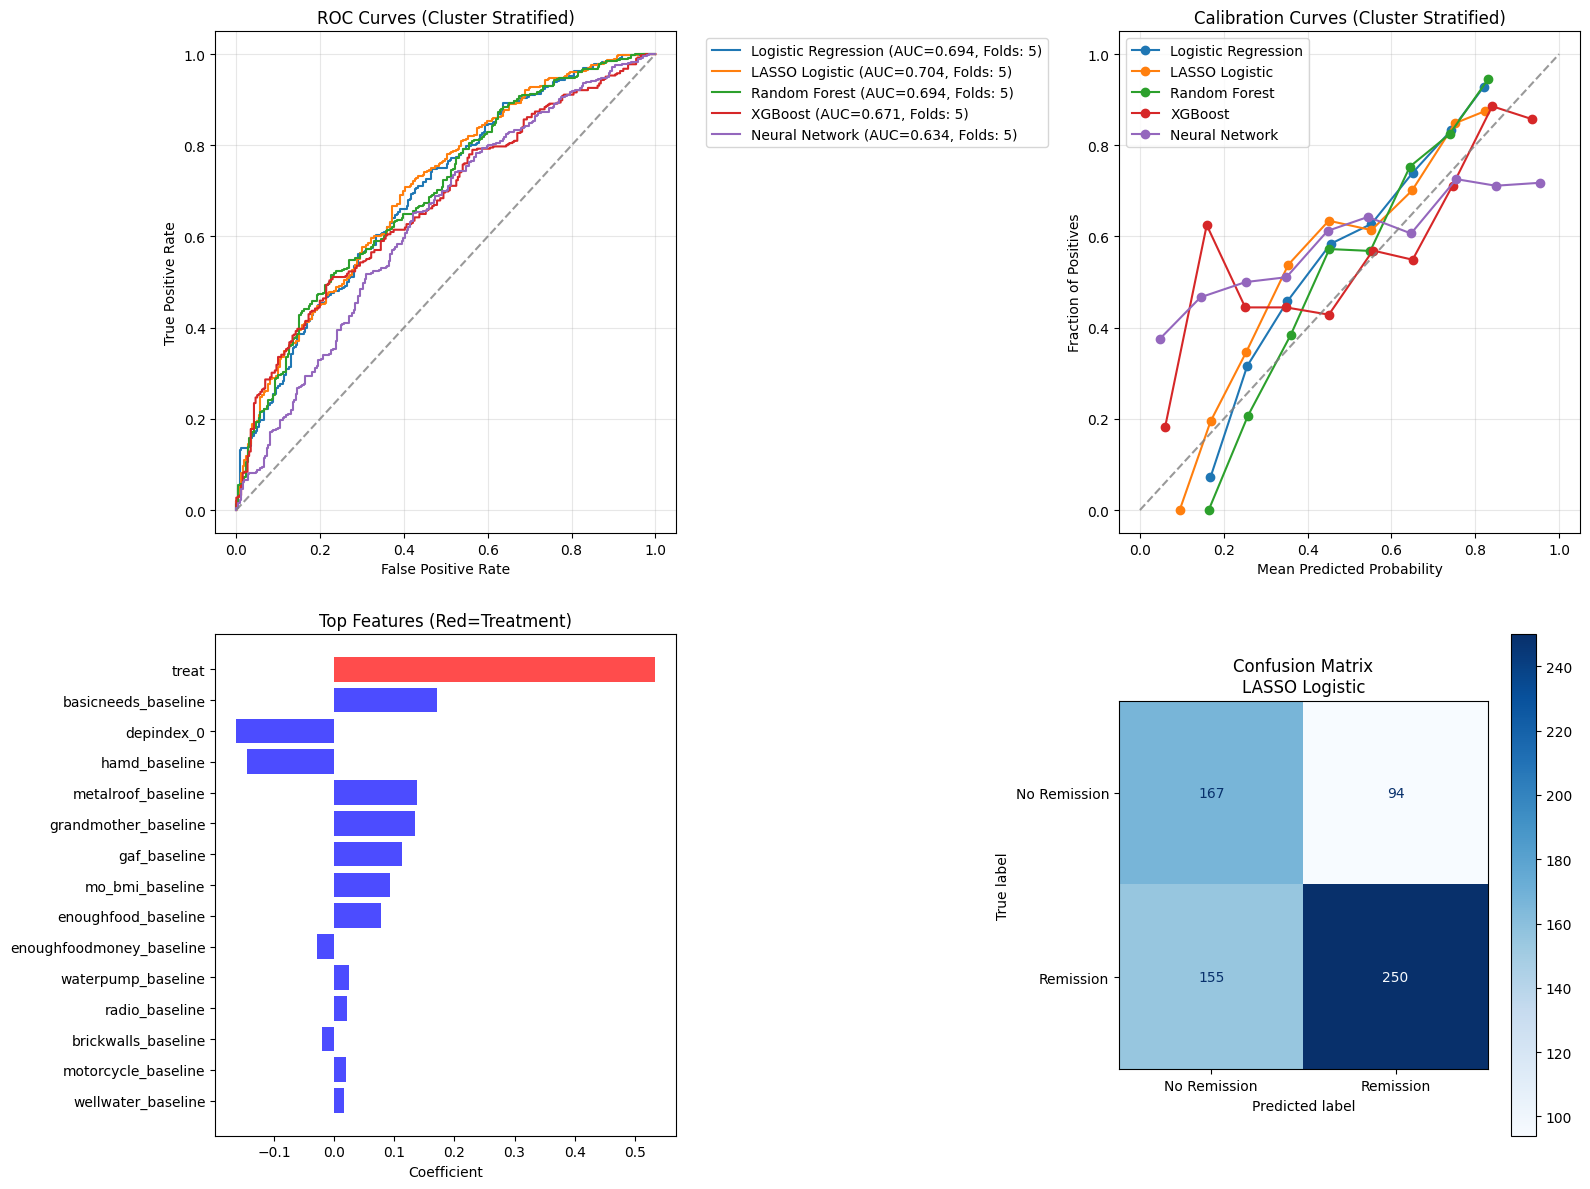

2025-07-26 18:07:39,940 - INFO - Refitted best: LASSO Logistic
2025-07-26 18:07:39,966 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.706, F1=0.637
Calibrated:   AUC=0.705, F1=0.735


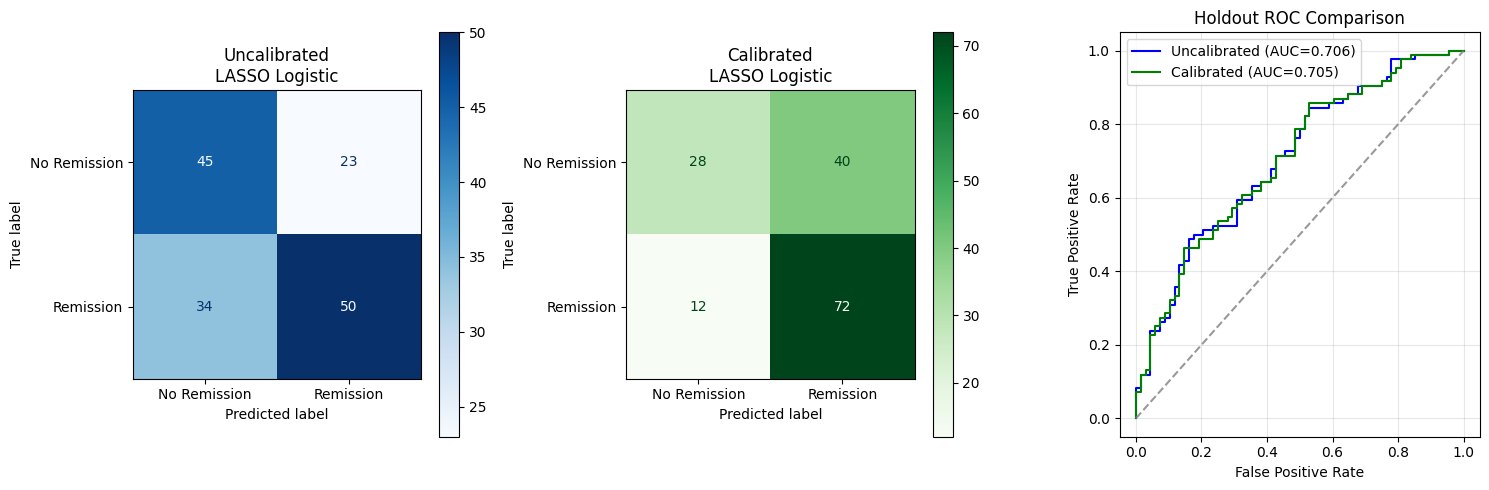

2025-07-26 18:07:40,290 - INFO - Performing SHAP analysis...
2025-07-26 18:07:40,292 - INFO - Treatment variable included in SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.625        0.658       
Precision       0.685        0.643       
Recall          0.595        0.857       
F1 Score        0.637        0.735       
AUC             0.706        0.705       
Specificity     0.662        0.412       
Sensitivity     0.595        0.857       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  50           72          
False Positives 23           40          
True Negatives  45           28          
False Negatives 34           12          


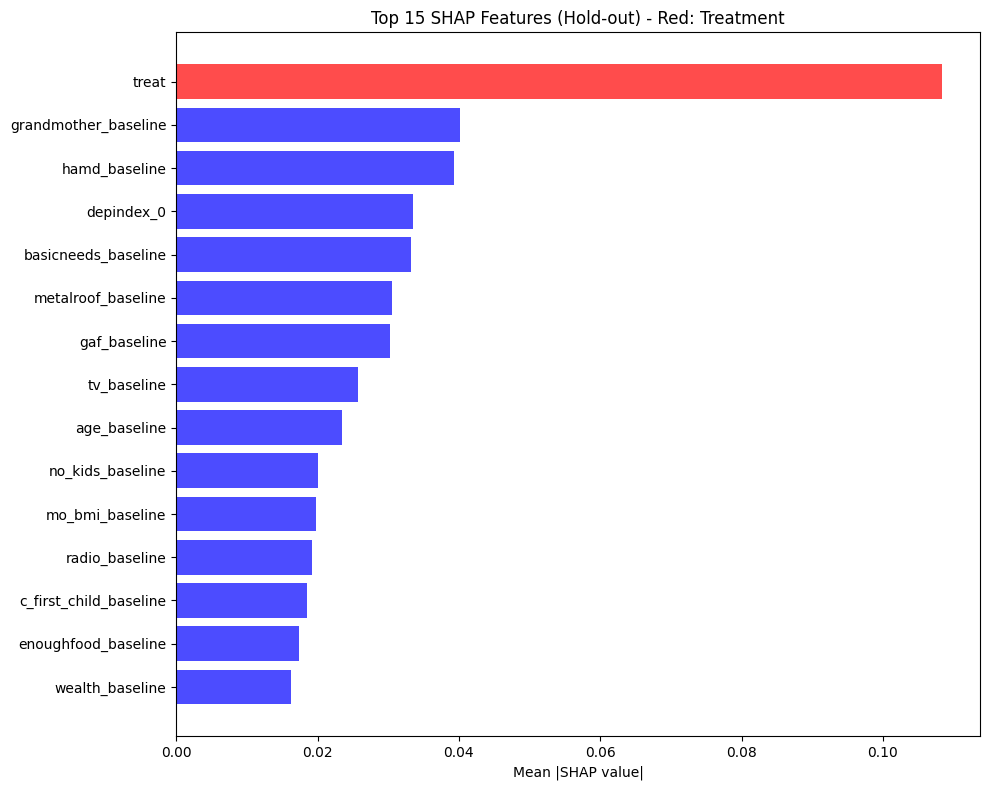

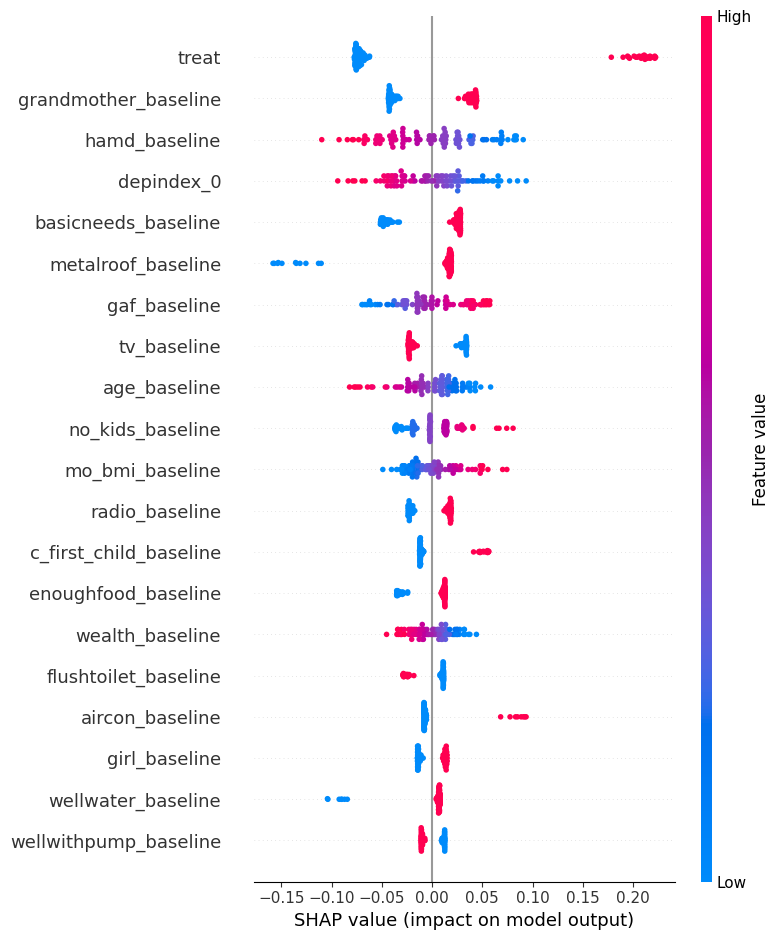


Generating SHAP Personas…
Top 3 SHAP features: ['hamd_baseline', 'grandmother_baseline', 'treat']

Top-3 SHAP Personas:
                                                    Profile  P(remission)
   hamd_baseline=low & grandmother_baseline=low & treat=low         0.612
  hamd_baseline=low & grandmother_baseline=low & treat=high         0.767
  hamd_baseline=low & grandmother_baseline=high & treat=low         0.658
 hamd_baseline=low & grandmother_baseline=high & treat=high         0.800
  hamd_baseline=high & grandmother_baseline=low & treat=low         0.457
 hamd_baseline=high & grandmother_baseline=low & treat=high         0.646
 hamd_baseline=high & grandmother_baseline=high & treat=low         0.509
hamd_baseline=high & grandmother_baseline=high & treat=high         0.691


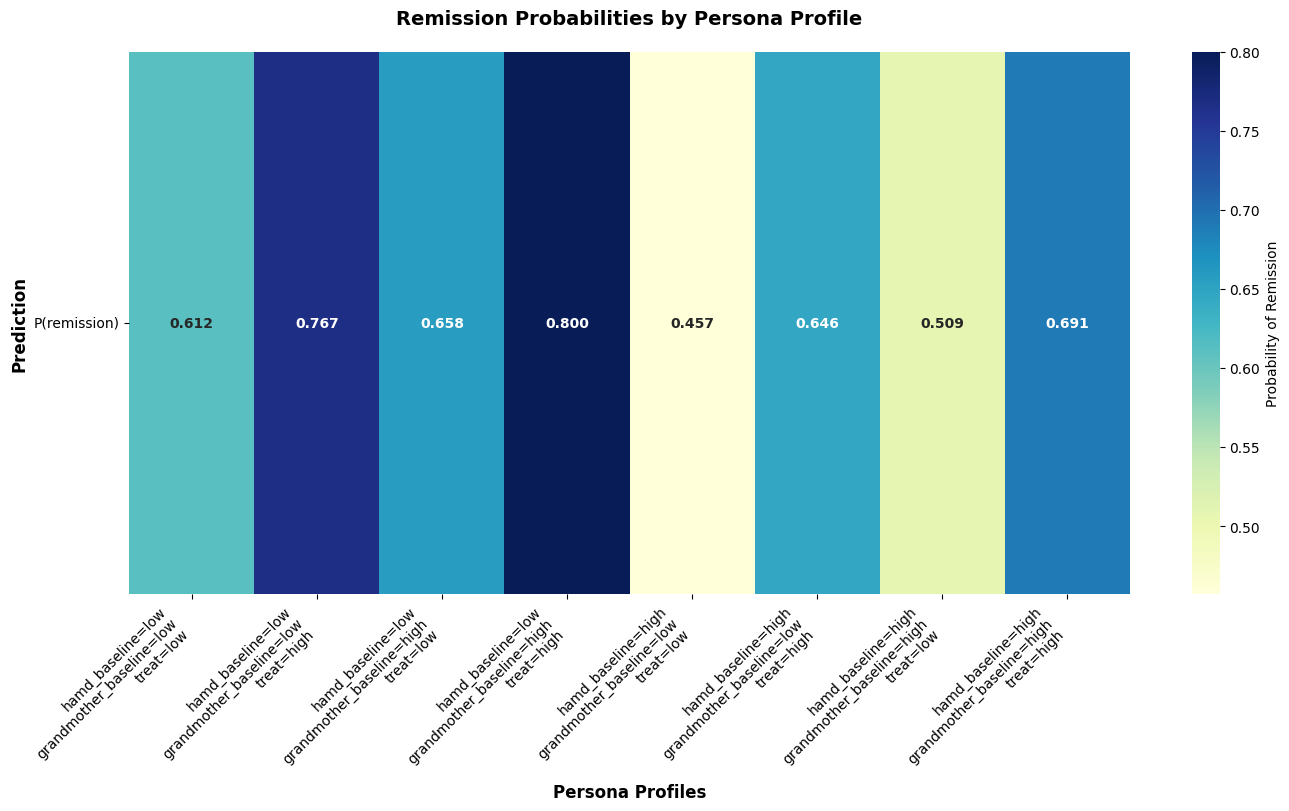

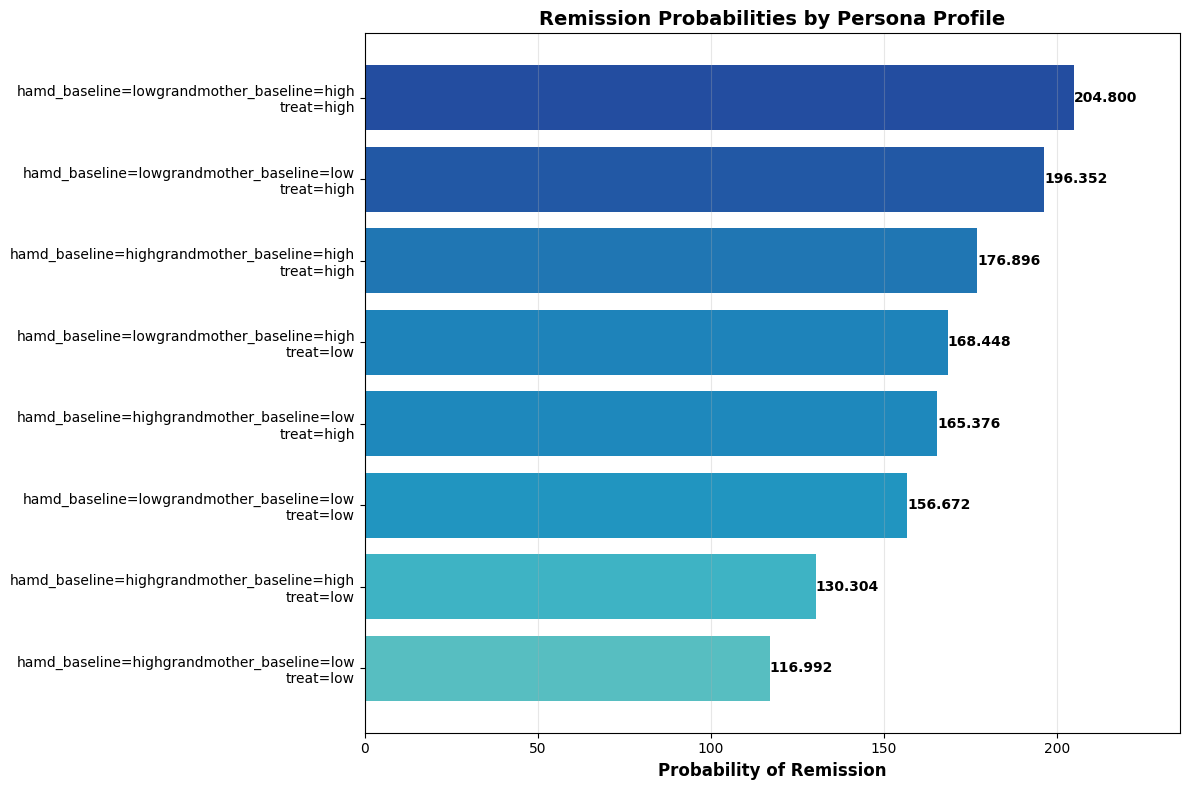


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Total folds: 5
  Average coefficient: 0.331
  Average importance: 0.000
LASSO Logistic:
  Total folds: 5
  Average coefficient: 0.548
  Average importance: 0.000
Random Forest:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.119
XGBoost:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.090
Neural Network:
  Total folds: 5
  Average coefficient: 0.000
  Average importance: 0.000

FINAL RESULTS SUMMARY
Best Model: LASSO Logistic
Hold-out Performance (Calibrated):
  Accuracy: 0.658
  Precision: 0.643
  Recall: 0.857
  F1 Score: 0.735
  AUC: 0.705
  Brier Score: 0.218
  True Negatives: 28.000
  False Positives: 40.000
  False Negatives: 12.000
  True Positives: 72.000
  Specificity: 0.412
  Sensitivity: 0.857
✓ Treatment variable was included in the model
  Treatment coefficient: 0.658
Training method: Cluster-stratified CV (no SMOTE, no feature selection)
Number of features used: 44


In [ ]:
# Remission at 6 months - no SMOTE, no univariate selection, cluster-stratified CV

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "remission_6mo"
    CLUSTER_COL: str = "uc"  # New: cluster column for stratification
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["remission_6mo", "uc"]  # Exclude cluster from features

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, cluster_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    assert cluster_col in df.columns, f"Cluster column '{cluster_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")
    logger.info(f"Clusters: {sorted(df[cluster_col].unique())}")
    logger.info(f"Target distribution: {df[target_col].value_counts().to_dict()}")

# ========= Cluster Stratification Utilities =========
def create_stratified_cluster_splits(df: pd.DataFrame, target_col: str, cluster_col: str, 
                                   test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Create stratified train/test split that maintains cluster separation and target distribution
    """
    # Create a stratification key combining cluster and target
    df['strat_key'] = df[cluster_col].astype(str) + '_' + df[target_col].astype(str)
    
    # Check if we have enough samples in each stratum
    strat_counts = df['strat_key'].value_counts()
    min_count = strat_counts.min()
    
    if min_count < 2:
        logger.warning(f"Some cluster-target combinations have <2 samples. Using simple cluster split.")
        # Fall back to cluster-only stratification
        clusters = df[cluster_col].unique()
        n_test_clusters = max(1, int(len(clusters) * test_size))
        np.random.seed(random_state)
        test_clusters = np.random.choice(clusters, n_test_clusters, replace=False)
        
        train_df = df[~df[cluster_col].isin(test_clusters)].copy()
        test_df = df[df[cluster_col].isin(test_clusters)].copy()
    else:
        # Use stratified split with cluster-target combination
        train_df, test_df = train_test_split(
            df, 
            test_size=test_size, 
            stratify=df['strat_key'],
            random_state=random_state
        )
    
    # Clean up temporary column
    train_df = train_df.drop('strat_key', axis=1)
    test_df = test_df.drop('strat_key', axis=1)
    
    logger.info(f"Train clusters: {sorted(train_df[cluster_col].unique())}")
    logger.info(f"Test clusters: {sorted(test_df[cluster_col].unique())}")
    logger.info(f"Train target dist: {train_df[target_col].value_counts().to_dict()}")
    logger.info(f"Test target dist: {test_df[target_col].value_counts().to_dict()}")
    
    return train_df, test_df

class ClusterStratifiedKFold:
    """
    Custom cross-validator that stratifies by cluster while maintaining target distribution
    """
    def __init__(self, n_splits: int = 5, shuffle: bool = True, random_state: int = None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
    
    def split(self, X, y, groups):
        """
        Generate cluster-stratified splits
        X: feature matrix
        y: target vector
        groups: cluster assignments
        """
        df = pd.DataFrame({'y': y, 'cluster': groups})
        clusters = df['cluster'].unique()
        
        if len(clusters) < self.n_splits:
            logger.warning(f"Only {len(clusters)} clusters available for {self.n_splits} splits. Using regular StratifiedKFold.")
            skf = StratifiedKFold(n_splits=self.n_splits, shuffle=self.shuffle, random_state=self.random_state)
            yield from skf.split(X, y)
            return
        
        # Create cluster folds
        np.random.seed(self.random_state)
        cluster_list = list(clusters)
        if self.shuffle:
            np.random.shuffle(cluster_list)
        
        cluster_folds = np.array_split(cluster_list, self.n_splits)
        
        for i in range(self.n_splits):
            test_clusters = set(cluster_folds[i])
            train_clusters = set(clusters) - test_clusters
            
            train_mask = df['cluster'].isin(train_clusters)
            test_mask = df['cluster'].isin(test_clusters)
            
            train_idx = df[train_mask].index.values
            test_idx = df[test_mask].index.values
            
            if len(train_idx) > 0 and len(test_idx) > 0:
                yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

# ========= UPDATED: Simple Pipeline Builder (No SMOTE, No Feature Selection) =========
def build_simple_pipeline(base_model, config: Config):
    """
    Build a simple pipeline with only preprocessing and model
    """
    pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', base_model)
    ])
    
    return pipeline

# ========= UPDATED: Nested CV with Cluster Stratification =========
def run_nested_cv_cluster_stratified(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                                    clusters: np.ndarray, config: Config) -> Dict[str, Any]:
    """
    Nested CV with cluster stratification, no SMOTE, no feature selection
    """
    outer_cv = ClusterStratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                    random_state=config.RANDOM_STATE)
    inner_cv = ClusterStratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                                    random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    treatment_selected_count = 0 
    treatment_scores = []  # Track treatment coefficients/importance

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, clusters)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            clusters_train_fold = clusters[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            cluster_dist = pd.Series(clusters_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")
            logger.info(f"Fold {fold+1} cluster distribution: {cluster_dist.to_dict()}")

            # Build simple pipeline (no SMOTE, no feature selection)
            pipe = build_simple_pipeline(model, config)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv.split(X_train_fold, y_train_fold, clusters_train_fold),
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Extract treatment coefficient/importance if available
            model_obj = best_model.named_steps['model']
            treat_importance = 0
            treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
            
            if hasattr(model_obj, 'coef_') and 'treat' in X_train_fold.columns:
                # Linear models
                treat_idx = X_train_fold.columns.get_loc('treat')
                treat_importance = abs(model_obj.coef_[0][treat_idx])
                treat_info['treat_coef'] = model_obj.coef_[0][treat_idx]
                logger.info(f"Fold {fold+1}: Treatment coefficient = {model_obj.coef_[0][treat_idx]:.3f}")
            elif hasattr(model_obj, 'feature_importances_') and 'treat' in X_train_fold.columns:
                # Tree-based models
                treat_idx = X_train_fold.columns.get_loc('treat')
                treat_importance = model_obj.feature_importances_[treat_idx]
                treat_info['treat_importance'] = treat_importance
                logger.info(f"Fold {fold+1}: Treatment importance = {treat_importance:.3f}")
            
            treatment_scores.append(treat_info)

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment importance summary
    if treatment_scores:
        avg_treat_coef = np.mean([t.get('treat_coef', 0) for t in treatment_scores])
        avg_treat_importance = np.mean([t.get('treat_importance', 0) for t in treatment_scores])
        logger.info(f"Average treatment coefficient: {avg_treat_coef:.3f}")
        logger.info(f"Average treatment importance: {avg_treat_importance:.3f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,  # Legacy compatibility
        "treatment_scores": treatment_scores
    }

# ========= UPDATED: Neural Network CV with Cluster Stratification =========
def run_nn_cv_cluster_stratified(X: pd.DataFrame, y: np.ndarray, clusters: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with cluster stratification, no SMOTE, no feature selection"""
    outer_cv = ClusterStratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                                    random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0  # Legacy compatibility
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, clusters)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing (no feature selection)
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_processed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_processed)
            
            logger.info(f"NN Fold {fold+1}: Training on {len(X_train_scaled)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Track treatment coefficient if possible (not applicable for NN, but keeping for consistency)
            treat_info = {'fold': fold + 1, 'treat_coef': 0, 'treat_importance': 0}
            treatment_scores.append(treat_info)
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_scaled.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_scaled) // 4))
            
            history = model.fit(
                X_train_scaled, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_processed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_processed)
            
            prob = model.predict(X_test_scaled, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Completed {successful_folds}/{config.OUTER_SPLITS} folds")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Updated - No Feature Selection) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    No feature selection included
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Updated) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

# ========= Enhanced plot_performance_curves Function (Updated) =========
def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, feature importance, and confusion matrix."""
    plt.figure(figsize=(16, 12))

    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    label = f"{name} (AUC={auc:.3f}, Folds: {res.get('successful_folds', 0)})"
                    plt.plot(fpr, tpr, label=label)
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")

    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    frac_pos, mean_pred = calibration_curve(y_valid, probs_valid, n_bins=10)
                    plt.plot(mean_pred, frac_pos, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")

    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    try:
        best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
        best_model = results[best_model_name]['model']

        if hasattr(best_model, 'named_steps'):
            model_obj = best_model.named_steps['model']
            if hasattr(model_obj, 'coef_'):
                coeffs = model_obj.coef_[0]
                top_idx = np.argsort(np.abs(coeffs))[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), coeffs[top_idx], color=colors, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Coefficient")
                plt.title("Top Features (Red=Treatment)")
            elif hasattr(model_obj, 'feature_importances_'):
                importances = model_obj.feature_importances_
                top_idx = np.argsort(importances)[-15:]
                top_feats = [feature_names[i] for i in top_idx]
                colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
                plt.barh(range(len(top_idx)), importances[top_idx], color=colors, alpha=0.7)
                plt.yticks(range(len(top_idx)), top_feats)
                plt.xlabel("Importance")
                plt.title("Top Features (Red=Treatment)")
            else:
                plt.text(0.5, 0.5, "Feature importance\nnot available", 
                         ha='center', va='center', transform=plt.gca().transAxes)
    except Exception as e:
        logger.warning(f"Error plotting feature importance: {e}")
        plt.text(0.5, 0.5, "Feature importance\nnot available", 
                 ha='center', va='center', transform=plt.gca().transAxes)

    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    try:
        res = results[best_model_name]
        valid_mask = res['y_probs'] >= 0
        if np.any(valid_mask):
            y_valid = y_true[valid_mask]
            y_pred_valid = res['y_preds'][valid_mask]

            cm = confusion_matrix(y_valid, y_pred_valid)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                          display_labels=['No Remission', 'Remission'])
            disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
            plt.title(f"Confusion Matrix\n{best_model_name}")
    except Exception as e:
        logger.warning(f"Error plotting confusion matrix: {e}")
        plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                 ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Remission', 'Remission'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Remission', 'Remission'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling (no feature selection)"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        # No feature selection - use all features
        X_for_shap = X_holdout
        shap_feature_names = feature_names
        
        # Highlight if treatment is included
        treat_included = 'treat' in shap_feature_names
        logger.info(f"Treatment variable included in SHAP: {treat_included}")
        
        n_background = min(100, X_for_shap.shape[0])
        background_data = X_for_shap[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(shap_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if shap_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [shap_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=shap_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'feature_names': shap_feature_names if 'shap_feature_names' in locals() else []
    }

# ========= UPDATED: Main Pipeline =========
def main():
    """UPDATED: Main execution pipeline with cluster stratification, no SMOTE, no feature selection"""

    # 1. Load & validate
    try:
        df = imputed_datasets["dat_ml_6m"]
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.CLUSTER_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, config.CLUSTER_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Cluster counts:\n{df[config.CLUSTER_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. Cluster-stratified train/hold-out split FIRST, before any processing
    train_df, holdout_df = create_stratified_cluster_splits(
        df, config.TARGET_COL, config.CLUSTER_COL, config.TEST_SIZE, config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    clusters_train = train_df[config.CLUSTER_COL].values
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training features: {len(feature_names)}")
    logger.info(f"Treatment variable included: {'treat' in feature_names}")

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with cluster stratification
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_cluster_stratified(
                model, params, X_train, y_train, clusters_train, config
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with cluster stratification
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_cluster_stratified(X_train, y_train, clusters_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (Cluster Stratified)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data (no SMOTE)
    X_train_proc = preprocessor.transform_features(X_train)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    logger.info(f"Final training data: {X_train_proc.shape}, class distribution: {np.bincount(y_train_processed)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(Cluster Stratified)")

    # 11. Refit best pipeline on full training data
    if not results:
        logger.error("No successful models to select from")
        return

    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]

    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return

    # Build and fit new pipeline on full processed data
    best_pipe = build_simple_pipeline(models_and_params[best_name][0], config)
    best_pipe.fit(X_train_proc, y_train_processed)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    calibrator = CalibratedClassifierCV(
        base_estimator=best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3
    )
    calibrator.fit(X_train_proc, y_train_processed)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated probabilities
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated probabilities
    probs_cal = calibrator.predict_proba(X_hold_proc)[:, 1]

    # Verify that calibration preserves prediction ranking
    spearman_corr = pd.Series(probs_unc).corr(pd.Series(probs_cal), method='spearman')
    print(f"Spearman correlation between calibrated and uncalibrated probabilities: {spearman_corr:.4f}")

    # 15) threshold predictions at 0.5 & calculate metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)

    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")

    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        sv = shap_info['shap_values']
        feats = shap_info['feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, calibrator):
                    self.preprocessor = preprocessor
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_proc)
            
            final_pipe = PersonaPipeline(preprocessor, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(remission)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(remission)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Remission'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Remission Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(remission)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(remission)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(remission)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(remission)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Remission', fontsize=12, fontweight='bold')
                    plt.title('Remission Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(remission)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_scores = result.get('treatment_scores', [])
            total_folds = result.get('successful_folds', 0)
            
            if treat_scores:
                avg_coef = np.mean([t.get('treat_coef', 0) for t in treat_scores])
                avg_importance = np.mean([t.get('treat_importance', 0) for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Total folds: {total_folds}")
                print(f"  Average coefficient: {avg_coef:.3f}")
                print(f"  Average importance: {avg_importance:.3f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was included
    if 'treat' in feature_names:
        print("✓ Treatment variable was included in the model")
        
        # Show treatment coefficient/importance for best model
        best_model_obj = best_pipe.named_steps['model']
        if hasattr(best_model_obj, 'coef_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_coef = best_model_obj.coef_[0][treat_idx]
            print(f"  Treatment coefficient: {treat_coef:.3f}")
        elif hasattr(best_model_obj, 'feature_importances_') and 'treat' in feature_names:
            treat_idx = feature_names.index('treat')
            treat_importance = best_model_obj.feature_importances_[treat_idx]
            print(f"  Treatment importance: {treat_importance:.3f}")
    else:
        print("⚠ Treatment variable was NOT included in the model")
    
    print(f"Training method: Cluster-stratified CV (no SMOTE, no feature selection)")
    print(f"Number of features used: {len(feature_names)}")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-09 16:58:20,438 - INFO - Data loaded: (489, 67)
2025-07-09 16:58:20,443 - INFO - Data validation passed. Shape: (489, 67)
2025-07-09 16:58:20,445 - INFO - Target counts:
relapse_1y
0    253
1    236
Name: count, dtype: int64
2025-07-09 16:58:20,447 - INFO - Missing values: 0
2025-07-09 16:58:20,461 - INFO - Train=391, Hold-out=98
2025-07-09 16:58:20,464 - INFO - → Nested CV: Logistic Regression
2025-07-09 16:58:20,467 - INFO - Processing outer fold 1/5
2025-07-09 16:58:20,468 - INFO - Fold 1 treatment distribution: {1: 194, 0: 118}
2025-07-09 16:58:20,469 - INFO - Fold 1 class distribution: {0: 161, 1: 151}
2025-07-09 16:58:23,517 - INFO - Fold 1: Treatment variable selected! (F-score=4.986, rank=8)
2025-07-09 16:58:23,519 - INFO - Fold 1 AUC: 0.571
2025-07-09 16:58:23,520 - INFO - Processing outer fold 2/5
2025-07-09 16:58:23,522 - INFO - Fold 2 treatment distribution: {1: 197, 0: 116}
2025-07-09 16:58:23,522 - INFO - Fold 2 class distribution: {0: 162, 1: 151}
2025-07-09 16:5


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.55  |       0.534 |    0.534 |      0.534 | 0.593 |         0.249 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.56  |       0.544 |    0.561 |      0.552 | 0.611 |         0.247 |       5 | 5/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.596 |       0.586 |    

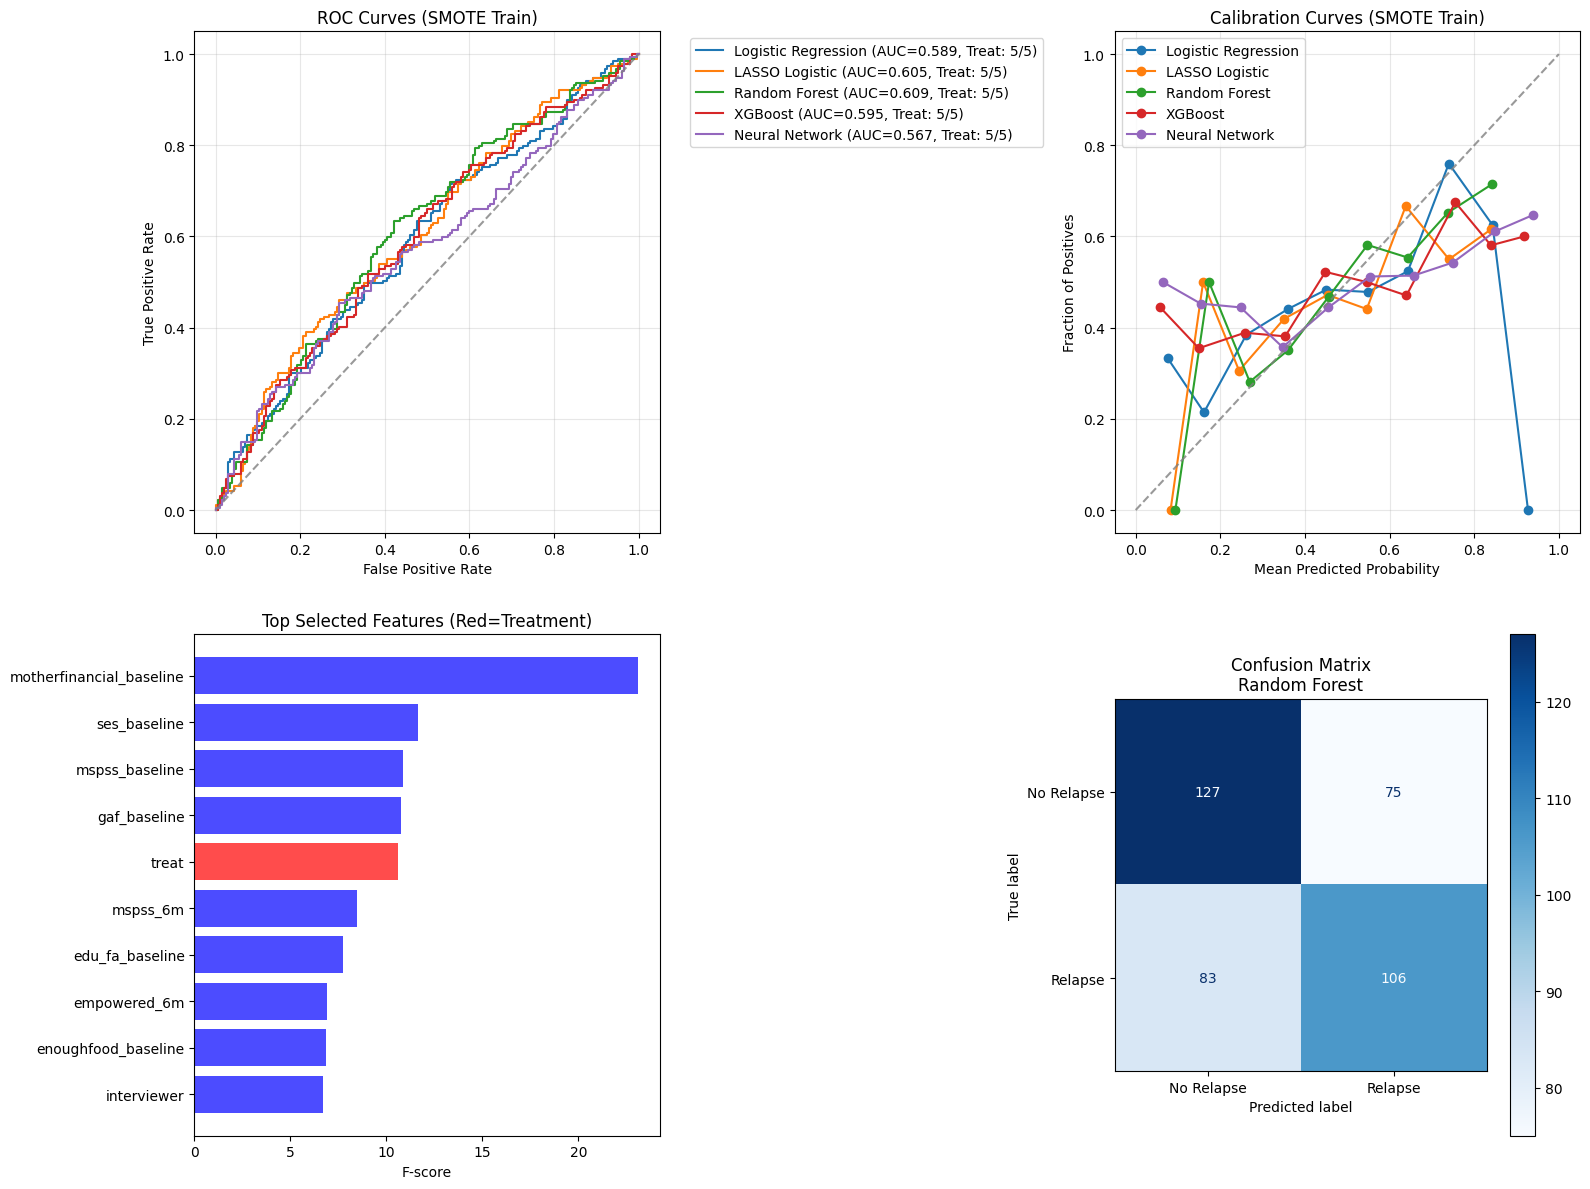

2025-07-09 17:00:21,151 - INFO - Refitted best: Random Forest
2025-07-09 17:00:21,349 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.621, F1=0.588
Calibrated:   AUC=0.632, F1=0.617


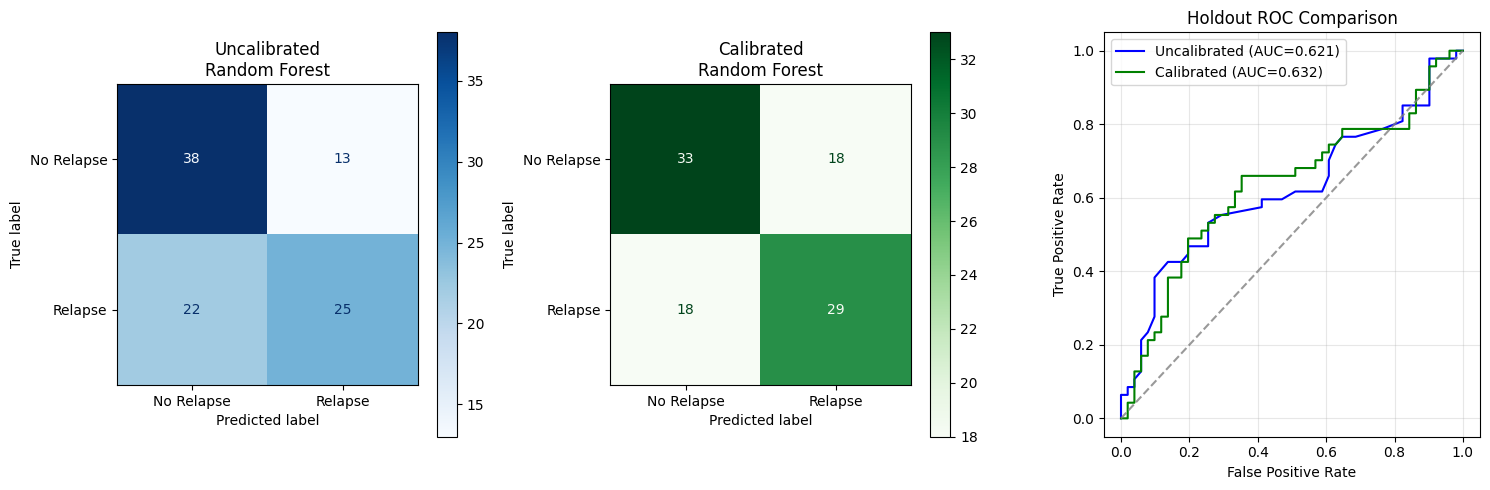

2025-07-09 17:00:21,629 - INFO - Performing SHAP analysis...
2025-07-09 17:00:21,630 - INFO - Treatment variable selected for SHAP: True



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.643        0.633       
Precision       0.658        0.617       
Recall          0.532        0.617       
F1 Score        0.588        0.617       
AUC             0.621        0.632       
Specificity     0.745        0.647       
Sensitivity     0.532        0.617       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  25           29          
False Positives 13           18          
True Negatives  38           33          
False Negatives 22           18          


PermutationExplainer explainer: 99it [00:15,  2.17it/s]                        


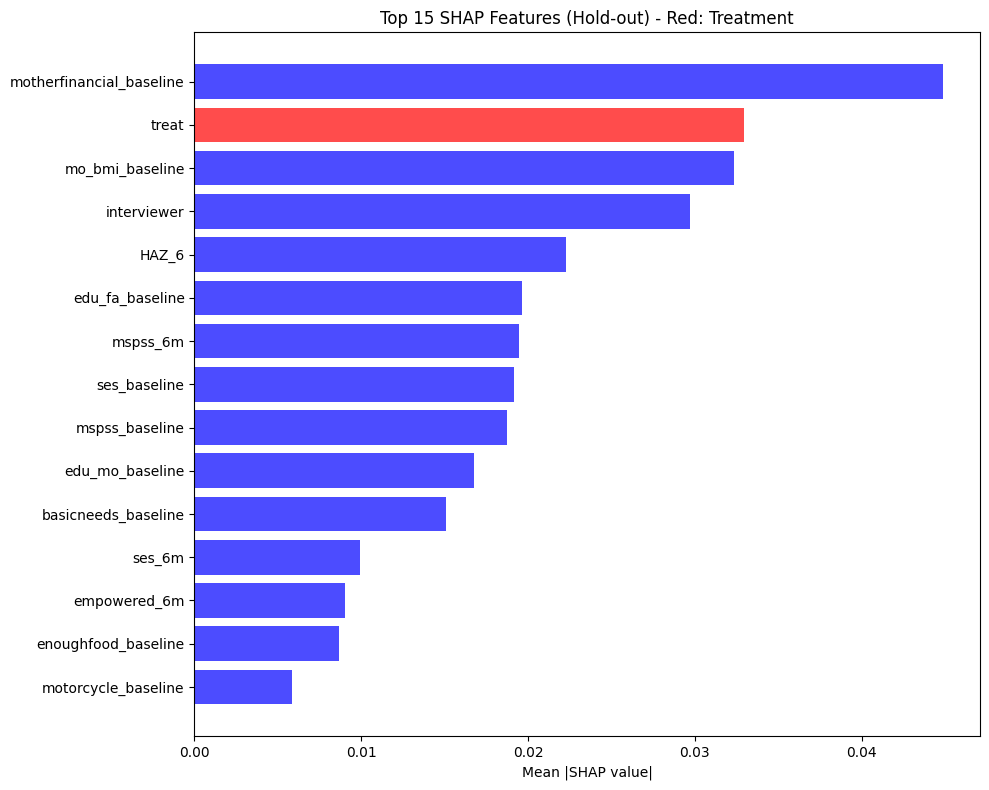

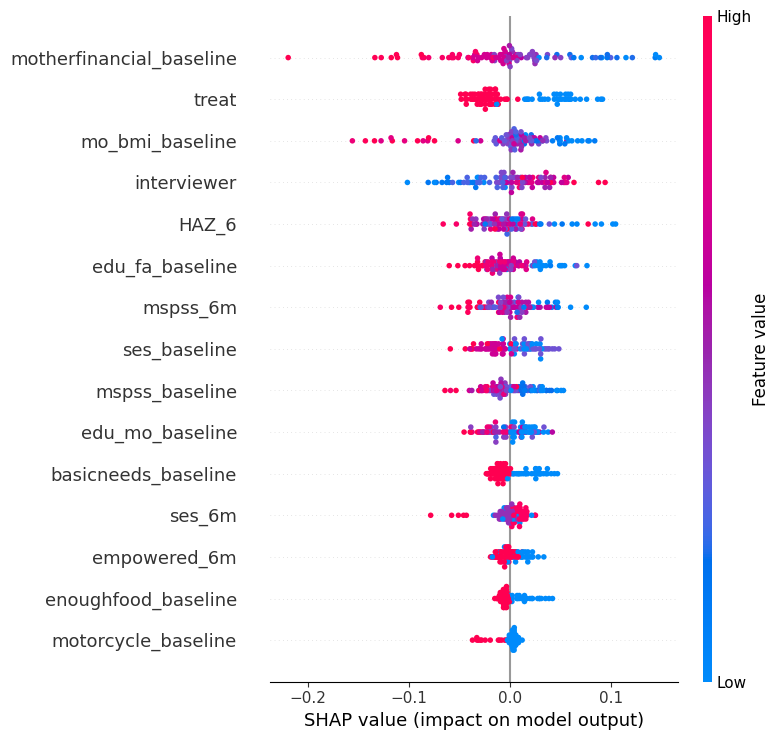


Generating SHAP Personas…
Top 3 SHAP features: ['mo_bmi_baseline', 'treat', 'motherfinancial_baseline']

Top-3 SHAP Personas:
                                                          Profile  P(relapse)
   mo_bmi_baseline=low & treat=low & motherfinancial_baseline=low       0.701
  mo_bmi_baseline=low & treat=low & motherfinancial_baseline=high       0.445
  mo_bmi_baseline=low & treat=high & motherfinancial_baseline=low       0.678
 mo_bmi_baseline=low & treat=high & motherfinancial_baseline=high       0.336
  mo_bmi_baseline=high & treat=low & motherfinancial_baseline=low       0.521
 mo_bmi_baseline=high & treat=low & motherfinancial_baseline=high       0.300
 mo_bmi_baseline=high & treat=high & motherfinancial_baseline=low       0.492
mo_bmi_baseline=high & treat=high & motherfinancial_baseline=high       0.252


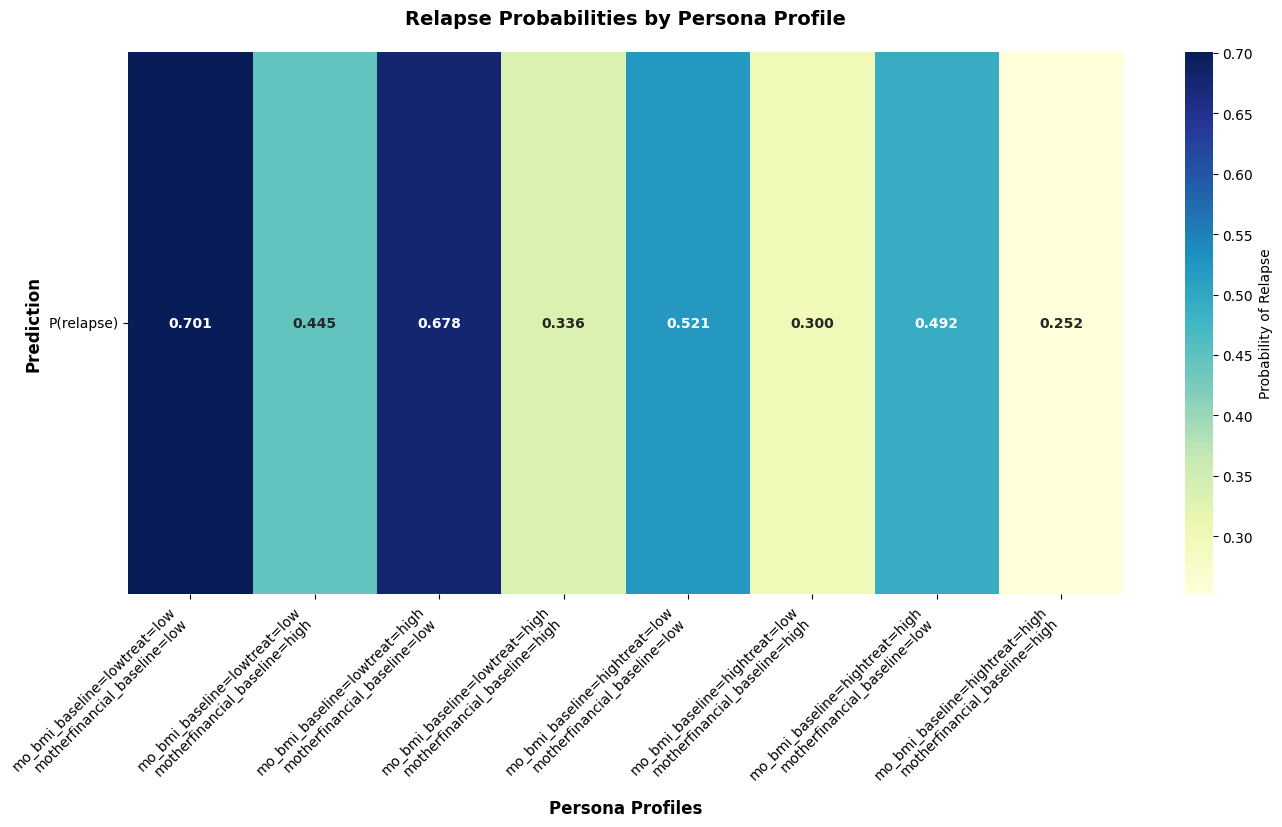

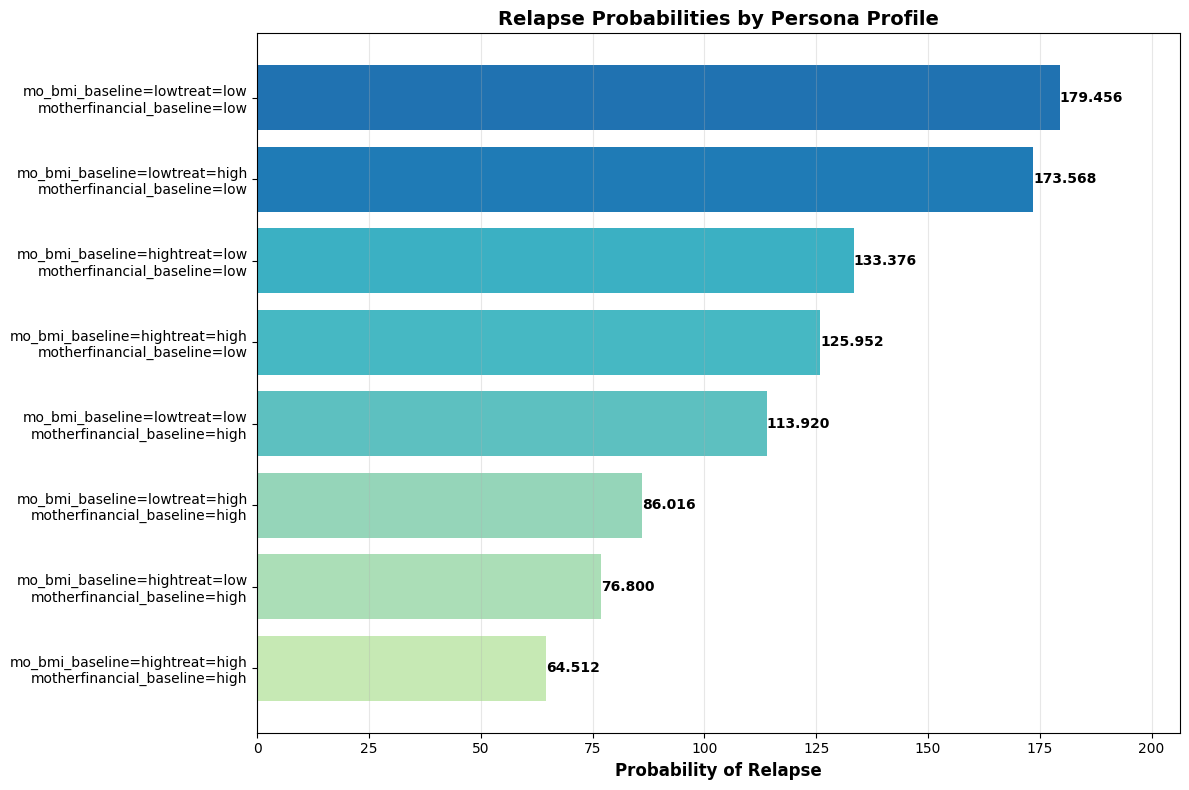


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 5/5 folds
  Average F-score: 8.183
  Average rank: 4.6
LASSO Logistic:
  Treatment selected: 5/5 folds
  Average F-score: 8.183
  Average rank: 4.6
Random Forest:
  Treatment selected: 5/5 folds
  Average F-score: 8.183
  Average rank: 4.6
XGBoost:
  Treatment selected: 5/5 folds
  Average F-score: 8.183
  Average rank: 4.6
Neural Network:
  Treatment selected: 5/5 folds
  Average F-score: 8.183
  Average rank: 4.6

FINAL RESULTS SUMMARY
Best Model: Random Forest
Hold-out Performance (Calibrated):
  Accuracy: 0.633
  Precision: 0.617
  Recall: 0.617
  F1 Score: 0.617
  AUC: 0.632
  Brier Score: 0.240
  True Negatives: 33.000
  False Positives: 18.000
  False Negatives: 18.000
  True Positives: 29.000
  Specificity: 0.647
  Sensitivity: 0.617
✓ Treatment variable was selected by the best model
Overall treatment selection rate: 25/25 (100.0%)


In [ ]:
# Relapse at 1 year - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "relapse_1y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["remission_6mo", "depressed_6m"

            ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Relapse', 'Relapse'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Relapse', 'Relapse'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_1y.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")


    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")


    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
        best_pipe,
        X_hold_proc,
        feature_names,
        preprocessor,
        holdout_df
    )

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(relapse)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(relapse)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Relapse'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Relapse Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(relapse)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(relapse)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(relapse)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(relapse)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Relapse', fontsize=12, fontweight='bold')
                    plt.title('Relapse Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(relapse)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-09 17:15:07,342 - INFO - Data loaded: (380, 88)
2025-07-09 17:15:07,343 - INFO - Data validation passed. Shape: (380, 88)
2025-07-09 17:15:07,344 - INFO - Target counts:
recurrence_7y
0    329
1     51
Name: count, dtype: int64
2025-07-09 17:15:07,346 - INFO - Missing values: 0
2025-07-09 17:15:07,349 - INFO - Train=304, Hold-out=76
2025-07-09 17:15:07,350 - INFO - → Nested CV: Logistic Regression
2025-07-09 17:15:07,351 - INFO - Processing outer fold 1/5
2025-07-09 17:15:07,353 - INFO - Fold 1 treatment distribution: {1: 164, 0: 79}
2025-07-09 17:15:07,354 - INFO - Fold 1 class distribution: {0: 210, 1: 33}
2025-07-09 17:15:11,738 - INFO - Fold 1: Treatment NOT selected (F-score=4.094, rank=48/83)
2025-07-09 17:15:11,743 - INFO - Fold 1 AUC: 0.573
2025-07-09 17:15:11,744 - INFO - Processing outer fold 2/5
2025-07-09 17:15:11,745 - INFO - Fold 2 treatment distribution: {1: 166, 0: 77}
2025-07-09 17:15:11,746 - INFO - Fold 2 class distribution: {0: 210, 1: 33}
2025-07-09 17:15:1


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.674 |       0.198 |    0.463 |      0.277 | 0.624 |         0.215 |       5 | 1/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.661 |       0.202 |    0.512 |      0.29  | 0.605 |         0.229 |       5 | 1/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.77  |       0.191 |    

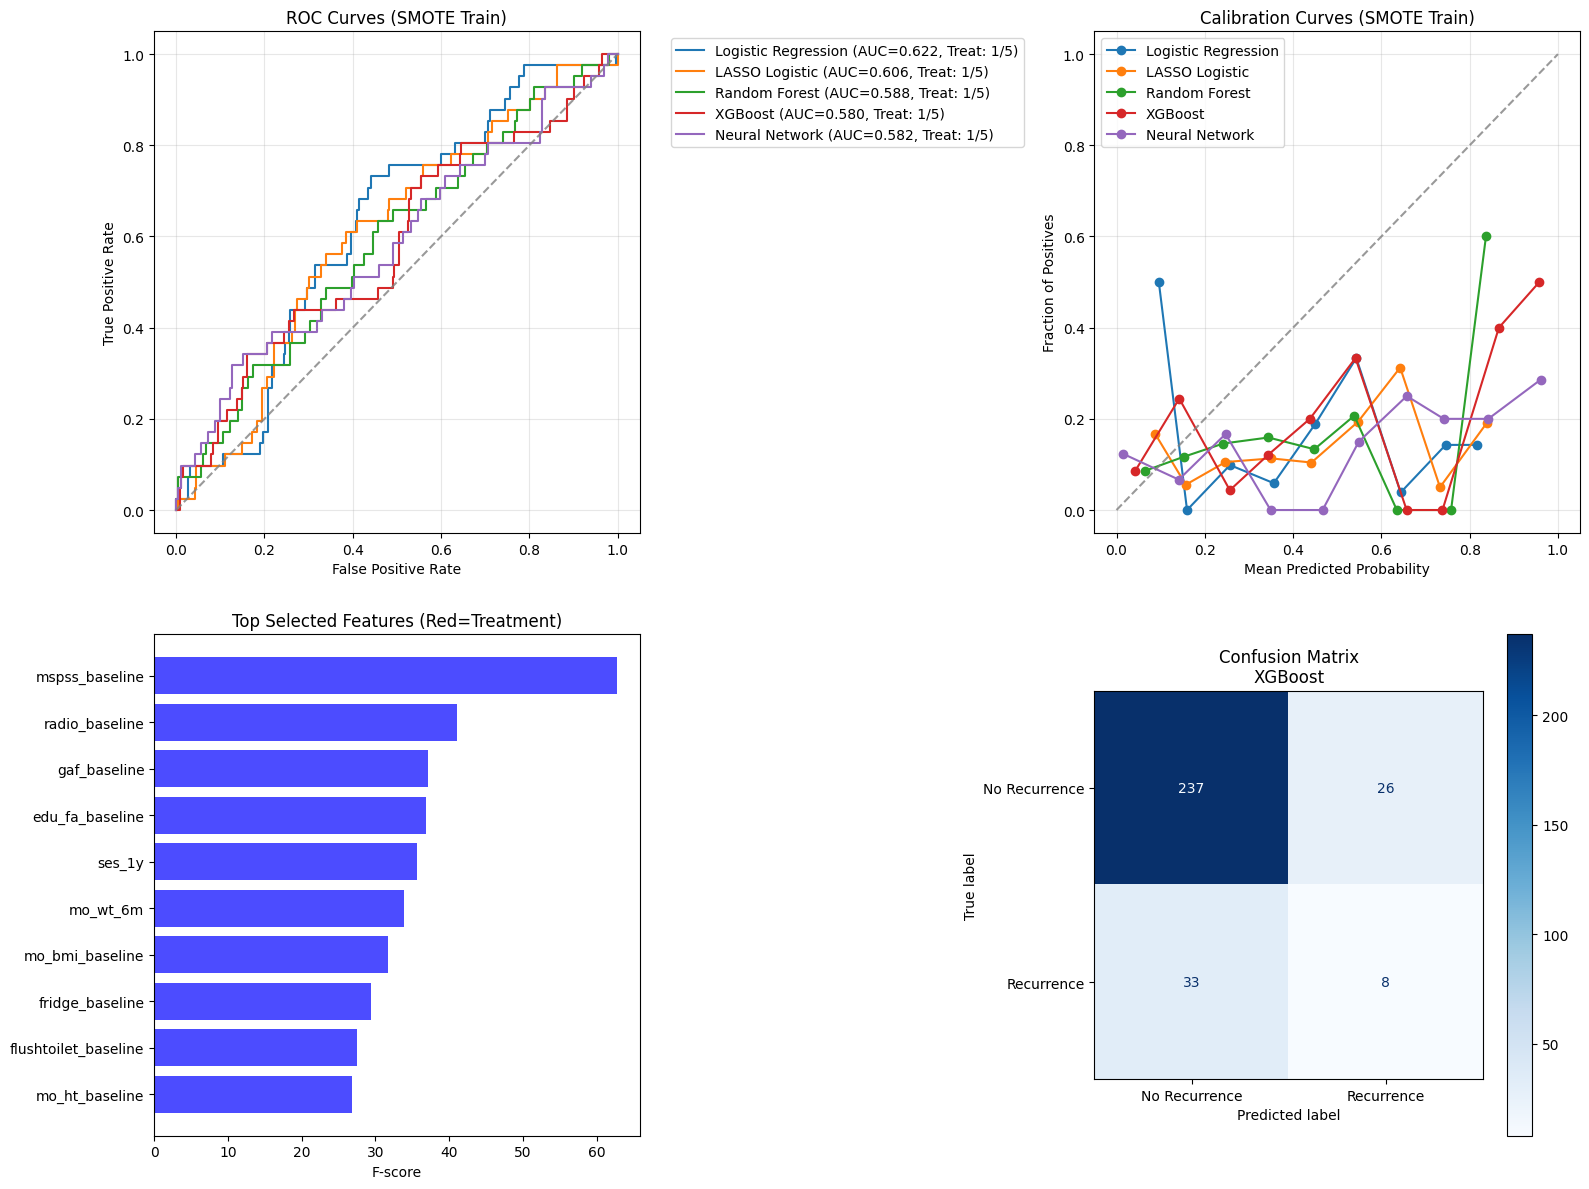

2025-07-09 17:17:22,212 - INFO - Refitted best: XGBoost
2025-07-09 17:17:22,285 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.620, F1=0.000
Calibrated:   AUC=0.618, F1=0.118


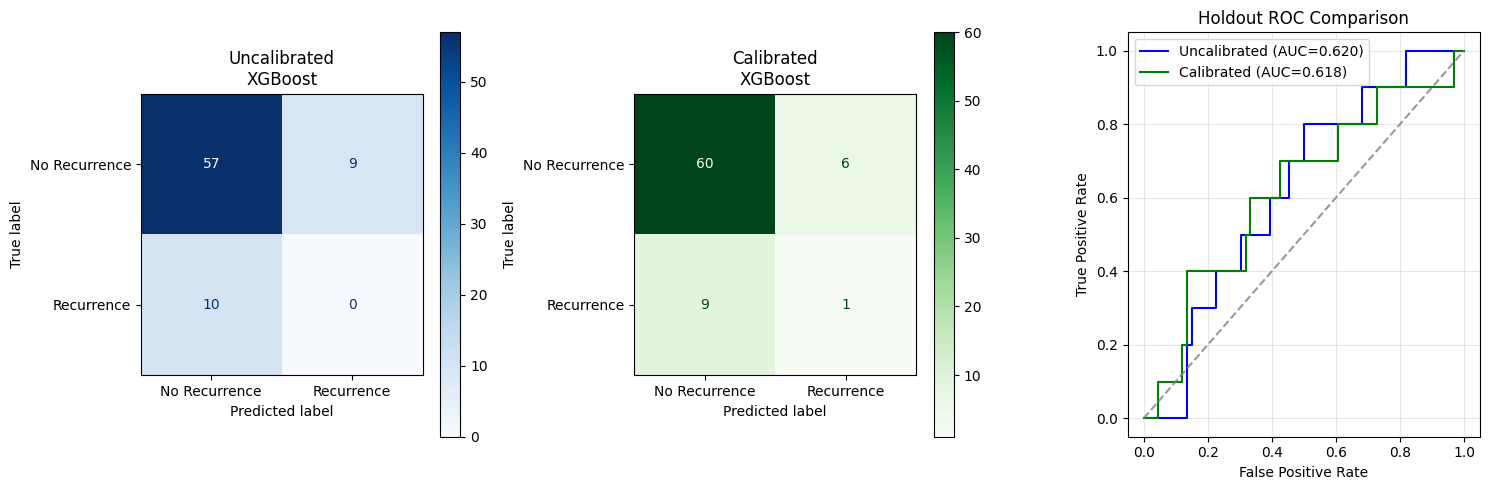

2025-07-09 17:17:22,530 - INFO - Performing SHAP analysis...
2025-07-09 17:17:22,533 - INFO - Treatment variable selected for SHAP: False



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.750        0.803       
Precision       0.000        0.143       
Recall          0.000        0.100       
F1 Score        0.000        0.118       
AUC             0.620        0.618       
Specificity     0.864        0.909       
Sensitivity     0.000        0.100       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  0            1           
False Positives 9            6           
True Negatives  57           60          
False Negatives 10           9           


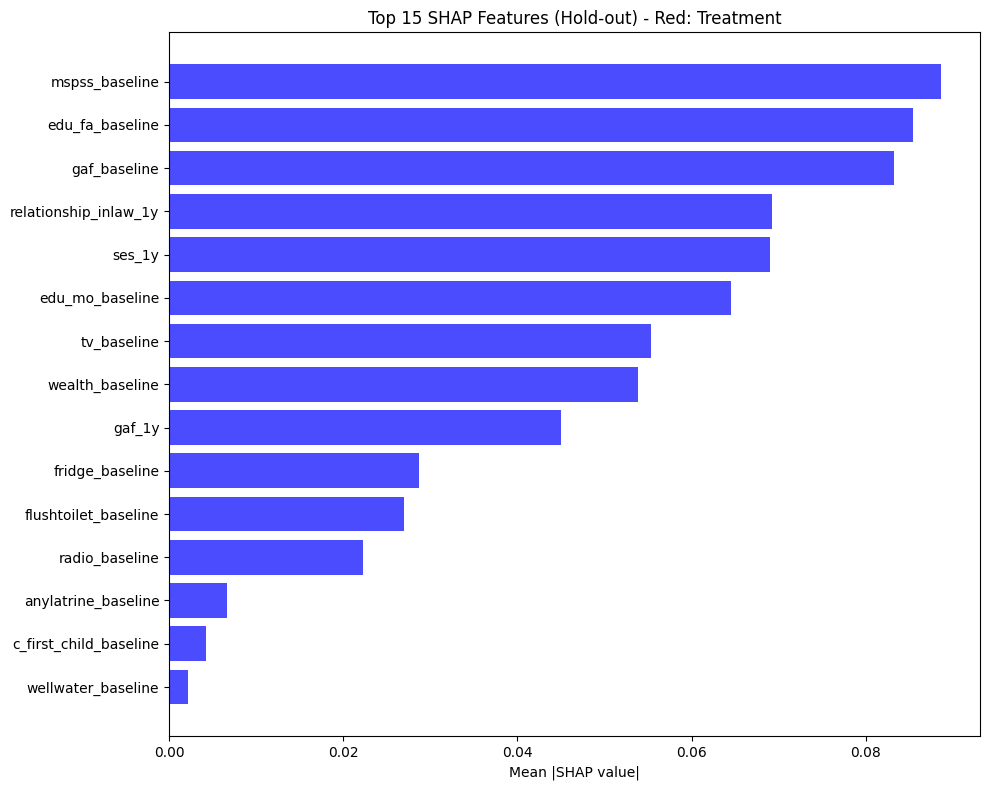

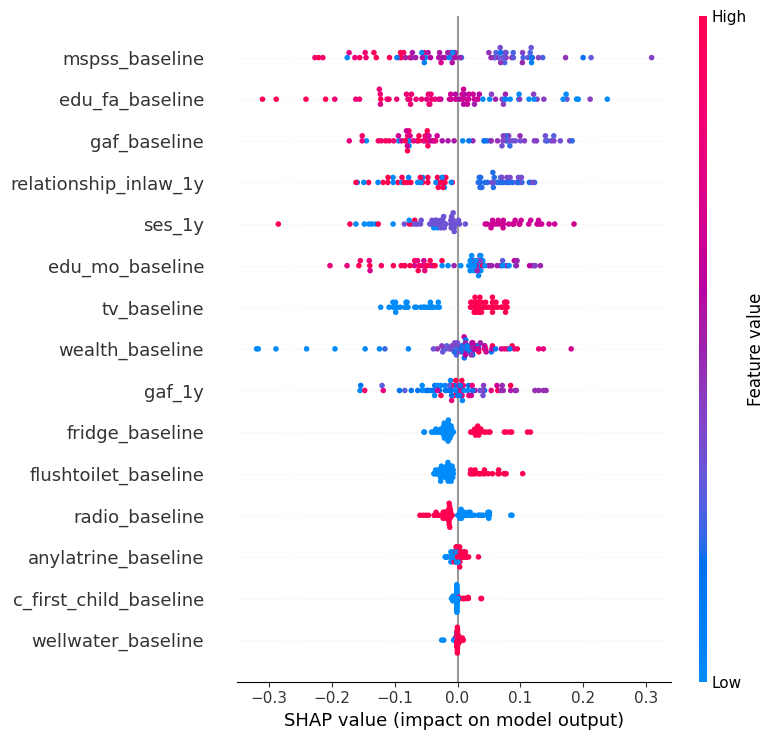


Generating SHAP Personas…
Top 3 SHAP features: ['gaf_baseline', 'edu_fa_baseline', 'mspss_baseline']

Top-3 SHAP Personas:
                                                       Profile  P(recurrence)
   gaf_baseline=low & edu_fa_baseline=low & mspss_baseline=low          0.874
  gaf_baseline=low & edu_fa_baseline=low & mspss_baseline=high          0.254
  gaf_baseline=low & edu_fa_baseline=high & mspss_baseline=low          0.090
 gaf_baseline=low & edu_fa_baseline=high & mspss_baseline=high          0.068
  gaf_baseline=high & edu_fa_baseline=low & mspss_baseline=low          0.814
 gaf_baseline=high & edu_fa_baseline=low & mspss_baseline=high          0.082
 gaf_baseline=high & edu_fa_baseline=high & mspss_baseline=low          0.072
gaf_baseline=high & edu_fa_baseline=high & mspss_baseline=high          0.067


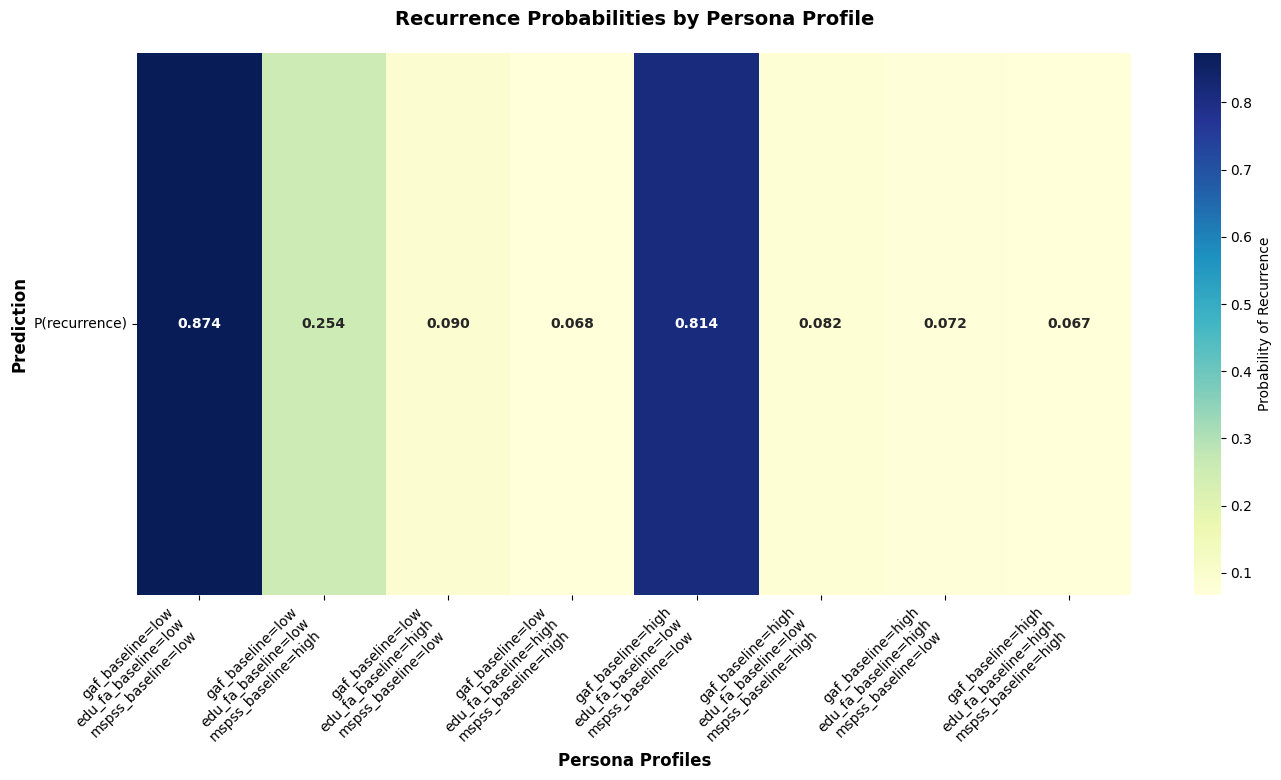

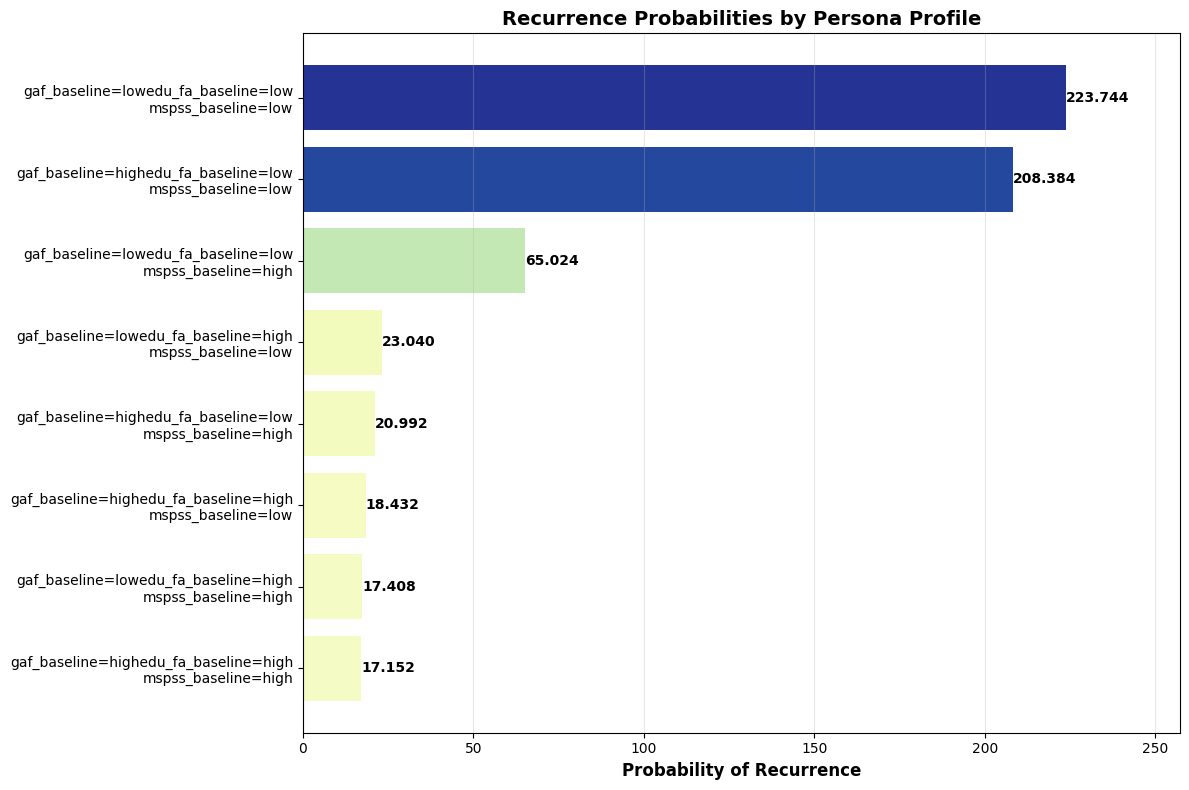


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 1/5 folds
  Average F-score: 6.021
  Average rank: 41.4
LASSO Logistic:
  Treatment selected: 1/5 folds
  Average F-score: 6.021
  Average rank: 41.4
Random Forest:
  Treatment selected: 1/5 folds
  Average F-score: 6.021
  Average rank: 41.4
XGBoost:
  Treatment selected: 1/5 folds
  Average F-score: 6.021
  Average rank: 41.4
Neural Network:
  Treatment selected: 1/5 folds
  Average F-score: 6.021
  Average rank: 41.4

FINAL RESULTS SUMMARY
Best Model: XGBoost
Hold-out Performance (Calibrated):
  Accuracy: 0.803
  Precision: 0.143
  Recall: 0.100
  F1 Score: 0.118
  AUC: 0.618
  Brier Score: 0.146
  True Negatives: 60.000
  False Positives: 6.000
  False Negatives: 9.000
  True Positives: 1.000
  Specificity: 0.909
  Sensitivity: 0.100
⚠ Treatment variable was NOT selected by the best model
Overall treatment selection rate: 5/25 (20.0%)


In [70]:
# Recurrence at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recurrence_7y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_6m", "recovery_1y", "depressed_1y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Recurrence', 'Recurrence'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Recurrence', 'Recurrence'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(recurrence)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(recurrence)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Recurrence'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Recurrence Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(recurrence)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(recurrence)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(recurrence)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(recurrence)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Recurrence', fontsize=12, fontweight='bold')
                    plt.title('Recurrence Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(recurrence)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-11 12:04:08,593 - INFO - Data loaded: (585, 89)
2025-07-11 12:04:08,597 - INFO - Data validation passed. Shape: (585, 89)
2025-07-11 12:04:08,600 - INFO - Target counts:
depressed_7y
0    426
1    159
Name: count, dtype: int64
2025-07-11 12:04:08,602 - INFO - Missing values: 301
2025-07-11 12:04:08,613 - INFO - Train=468, Hold-out=117
2025-07-11 12:04:08,617 - INFO - → Nested CV: Logistic Regression
2025-07-11 12:04:08,619 - INFO - Processing outer fold 1/5
2025-07-11 12:04:08,620 - INFO - Fold 1 treatment distribution: {0: 193, 1: 181}
2025-07-11 12:04:08,620 - INFO - Fold 1 class distribution: {0: 273, 1: 101}
2025-07-11 12:04:11,974 - INFO - Fold 1: Treatment NOT selected (F-score=11.633, rank=39/86)
2025-07-11 12:04:11,978 - INFO - Fold 1 AUC: 0.581
2025-07-11 12:04:11,979 - INFO - Processing outer fold 2/5
2025-07-11 12:04:11,980 - INFO - Fold 2 treatment distribution: {0: 190, 1: 184}
2025-07-11 12:04:11,981 - INFO - Fold 2 class distribution: {0: 273, 1: 101}
2025-07-11 


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.65  |       0.4   |    0.583 |      0.474 | 0.655 |         0.23  |       5 | 0/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.622 |       0.382 |    0.638 |      0.478 | 0.654 |         0.24  |       5 | 0/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.626 |       0.372 |    

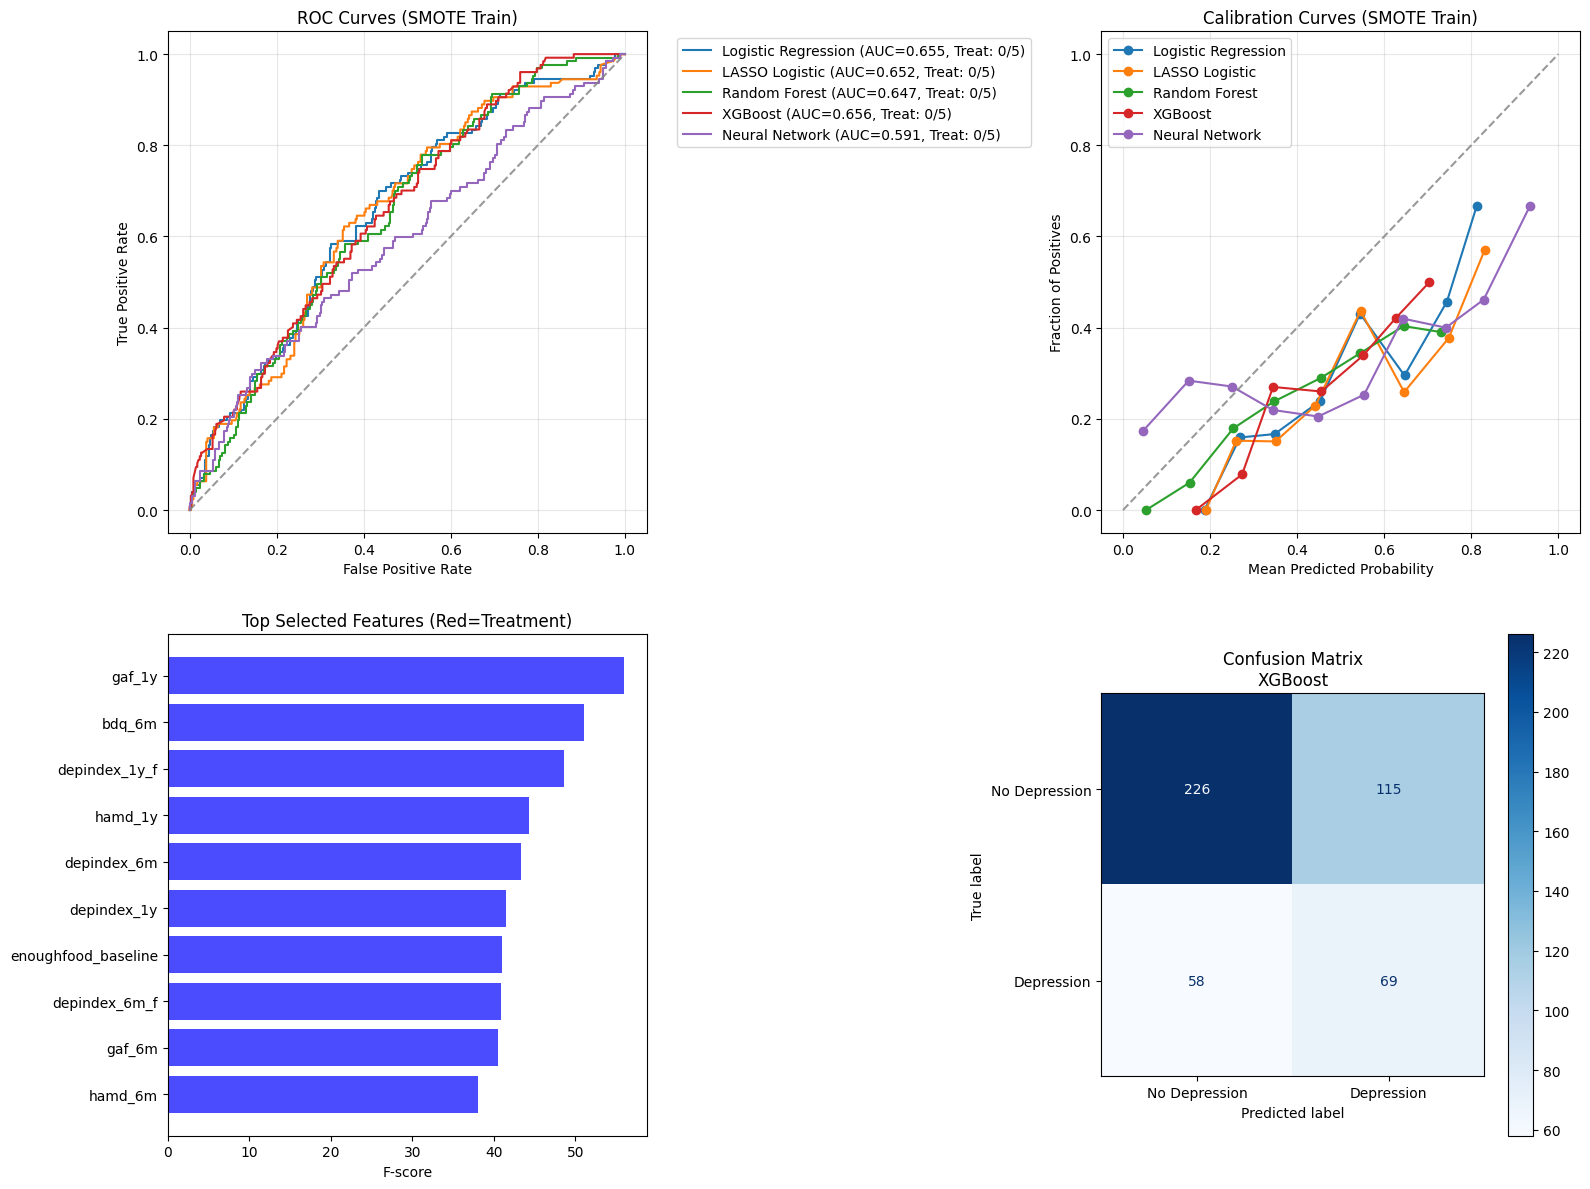

2025-07-11 12:06:12,942 - INFO - Refitted best: XGBoost
2025-07-11 12:06:13,059 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.714, F1=0.357
Calibrated:   AUC=0.736, F1=0.407


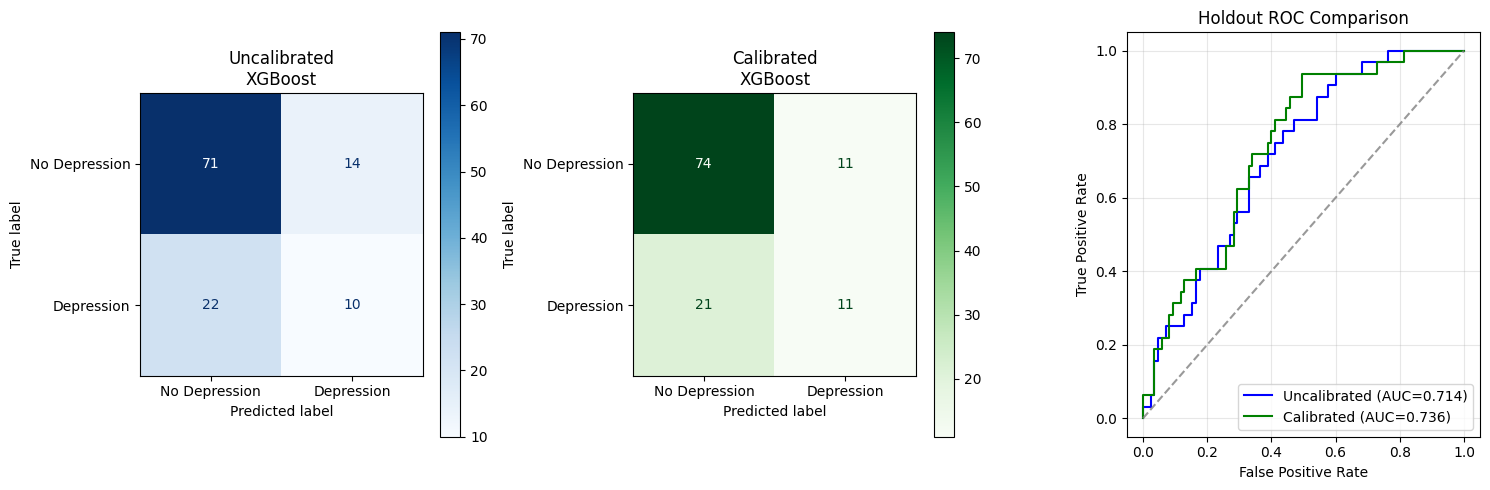

2025-07-11 12:06:13,342 - INFO - Performing SHAP analysis...
2025-07-11 12:06:13,343 - INFO - Treatment variable selected for SHAP: False



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.692        0.726       
Precision       0.417        0.500       
Recall          0.312        0.344       
F1 Score        0.357        0.407       
AUC             0.714        0.736       
Specificity     0.835        0.871       
Sensitivity     0.312        0.344       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  10           11          
False Positives 14           11          
True Negatives  71           74          
False Negatives 22           21          


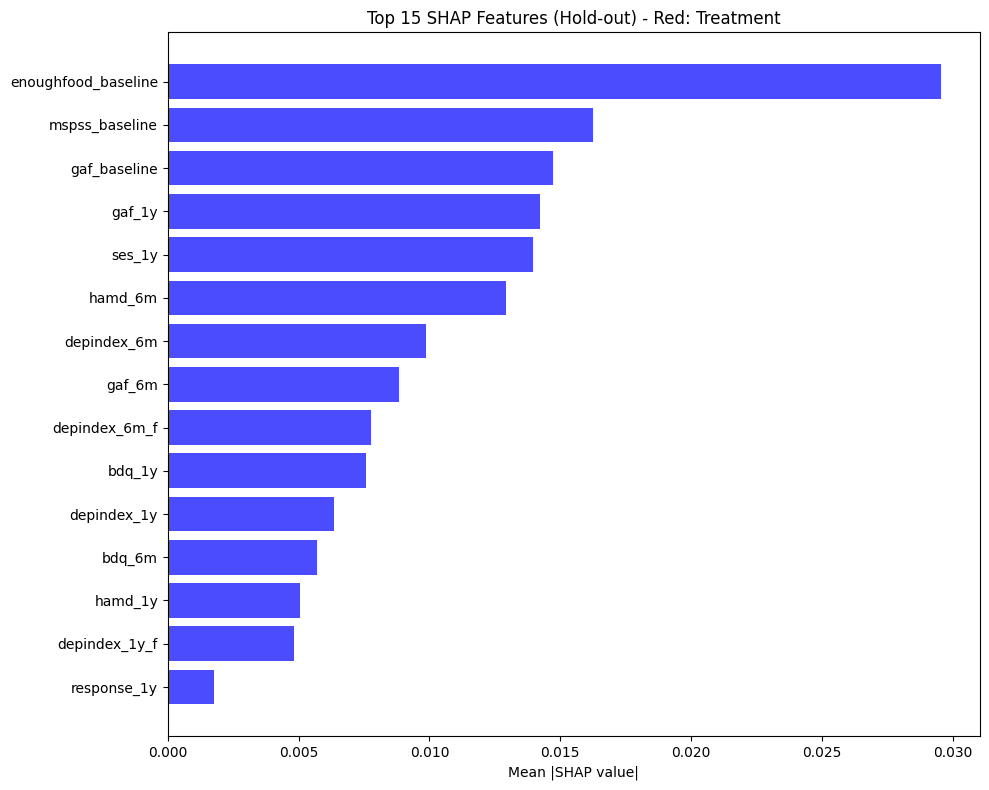

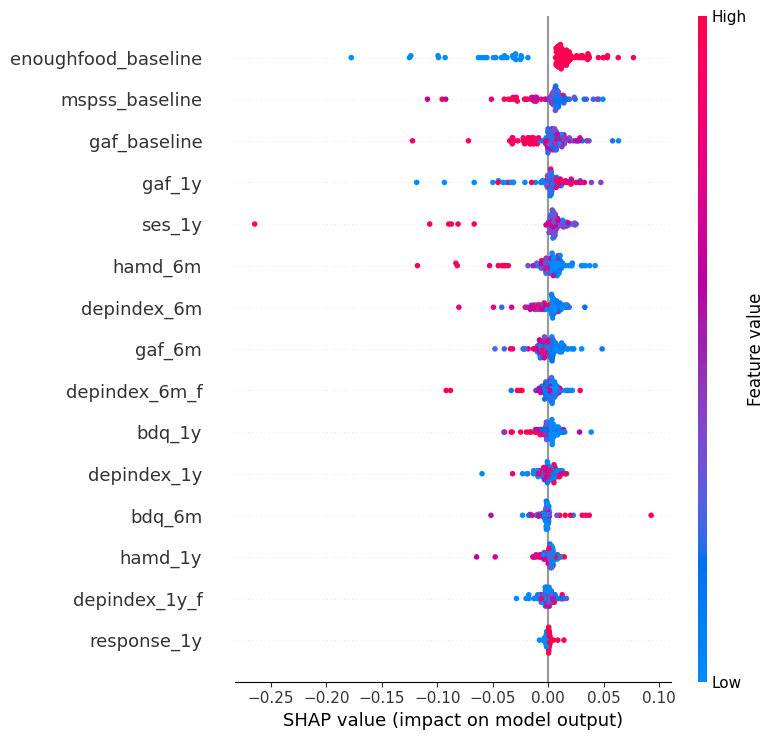


Generating SHAP Personas…
Top 3 SHAP features: ['gaf_baseline', 'mspss_baseline', 'enoughfood_baseline']

Top-3 SHAP Personas:
                                                           Profile  P(depression)
   gaf_baseline=low & mspss_baseline=low & enoughfood_baseline=low          0.558
  gaf_baseline=low & mspss_baseline=low & enoughfood_baseline=high          0.222
  gaf_baseline=low & mspss_baseline=high & enoughfood_baseline=low          0.298
 gaf_baseline=low & mspss_baseline=high & enoughfood_baseline=high          0.185
  gaf_baseline=high & mspss_baseline=low & enoughfood_baseline=low          0.572
 gaf_baseline=high & mspss_baseline=low & enoughfood_baseline=high          0.177
 gaf_baseline=high & mspss_baseline=high & enoughfood_baseline=low          0.311
gaf_baseline=high & mspss_baseline=high & enoughfood_baseline=high          0.188


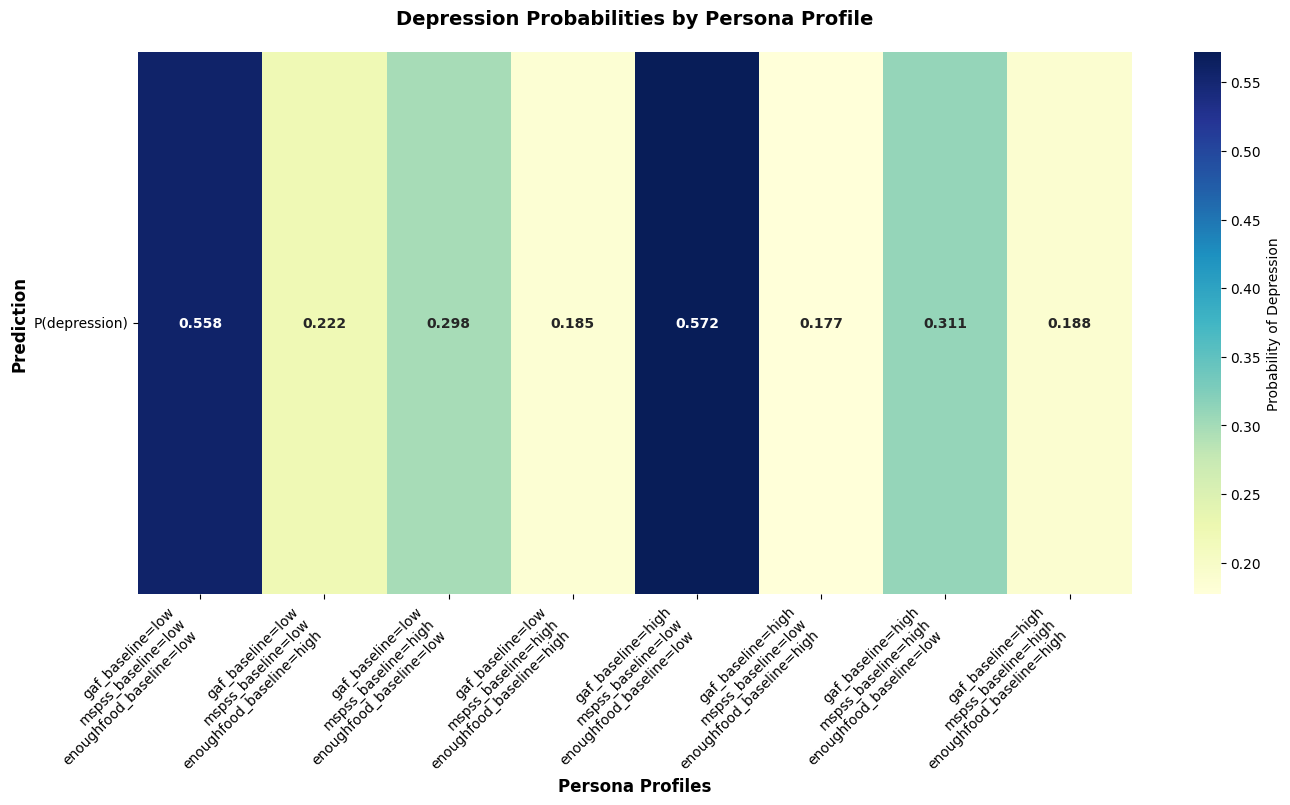

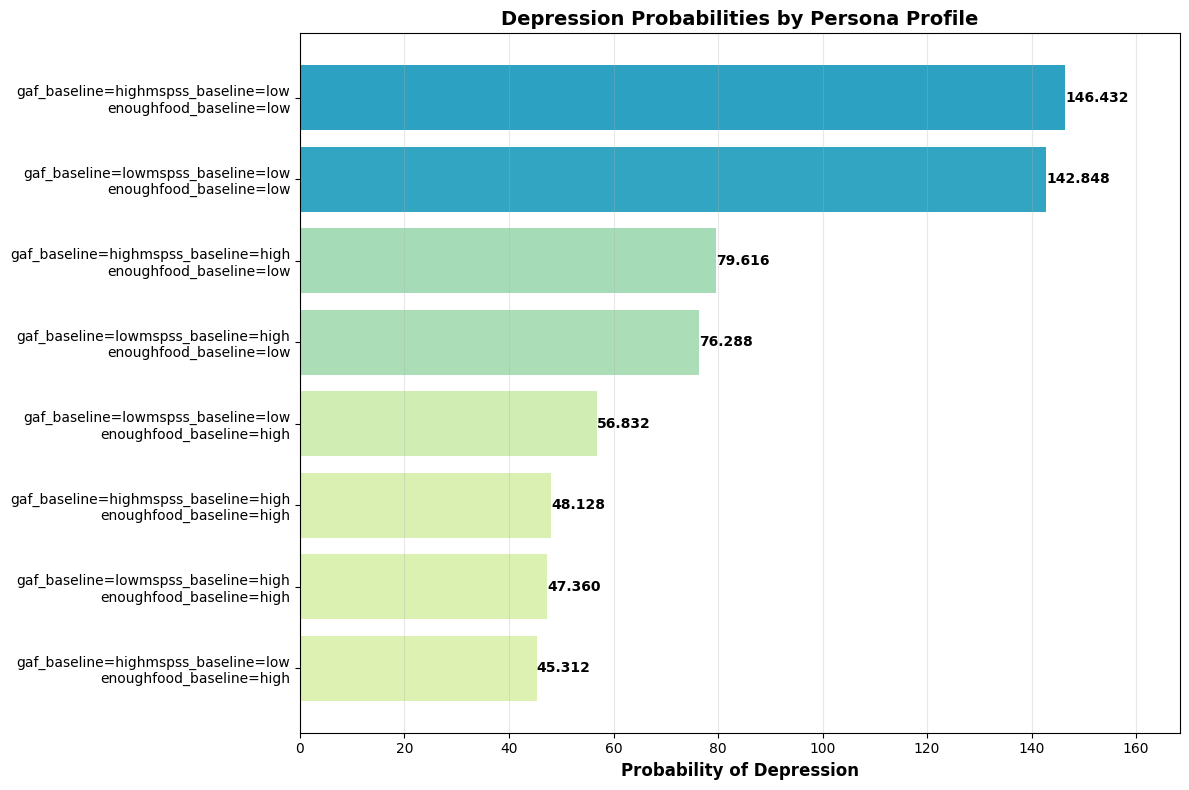


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
LASSO Logistic:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
Random Forest:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
XGBoost:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6
Neural Network:
  Treatment selected: 0/5 folds
  Average F-score: 7.592
  Average rank: 47.6

FINAL RESULTS SUMMARY
Best Model: XGBoost
Hold-out Performance (Calibrated):
  Accuracy: 0.726
  Precision: 0.500
  Recall: 0.344
  F1 Score: 0.407
  AUC: 0.736
  Brier Score: 0.188
  True Negatives: 74.000
  False Positives: 11.000
  False Negatives: 21.000
  True Positives: 11.000
  Specificity: 0.871
  Sensitivity: 0.344
⚠ Treatment variable was NOT selected by the best model
Overall treatment selection rate: 0/25 (0.0%)


In [74]:
# Depression at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "depressed_7y"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "depressed_7y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['No Depression', 'Depression'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['No Depression', 'Depression'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['No Depression', 'Depression'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y_dep.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(depression)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(depression)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Depression'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Depression Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(depression)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(depression)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(depression)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(depression)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Depression', fontsize=12, fontweight='bold')
                    plt.title('Depression Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(depression)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()

2025-07-10 09:03:00,835 - INFO - Data loaded: (903, 89)
2025-07-10 09:03:00,840 - INFO - Data validation passed. Shape: (903, 89)
2025-07-10 09:03:00,843 - INFO - Target counts:
recover_never
0    810
1     93
Name: count, dtype: int64
2025-07-10 09:03:00,845 - INFO - Missing values: 0
2025-07-10 09:03:00,854 - INFO - Train=722, Hold-out=181
2025-07-10 09:03:00,857 - INFO - → Nested CV: Logistic Regression
2025-07-10 09:03:00,859 - INFO - Processing outer fold 1/5
2025-07-10 09:03:00,864 - INFO - Fold 1 treatment distribution: {0: 291, 1: 286}
2025-07-10 09:03:00,866 - INFO - Fold 1 class distribution: {0: 518, 1: 59}
2025-07-10 09:03:04,419 - INFO - Fold 1: Treatment NOT selected (F-score=102.349, rank=18/83)
2025-07-10 09:03:04,424 - INFO - Fold 1 AUC: 0.889
2025-07-10 09:03:04,425 - INFO - Processing outer fold 2/5
2025-07-10 09:03:04,427 - INFO - Fold 2 treatment distribution: {1: 300, 0: 277}
2025-07-10 09:03:04,427 - INFO - Fold 2 class distribution: {0: 518, 1: 59}
2025-07-10 09


Nested CV Performance (with Treatment Selection)
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   AUC |   Brier Score |   Folds | Treat_Selected   |
+=====================+============+=============+==========+============+=======+===============+=========+==================+
| Logistic Regression |      0.755 |       0.279 |    0.878 |      0.423 | 0.87  |         0.15  |       5 | 2/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| LASSO Logistic      |      0.749 |       0.276 |    0.892 |      0.422 | 0.873 |         0.152 |       5 | 2/5              |
+---------------------+------------+-------------+----------+------------+-------+---------------+---------+------------------+
| Random Forest       |      0.819 |       0.325 |    

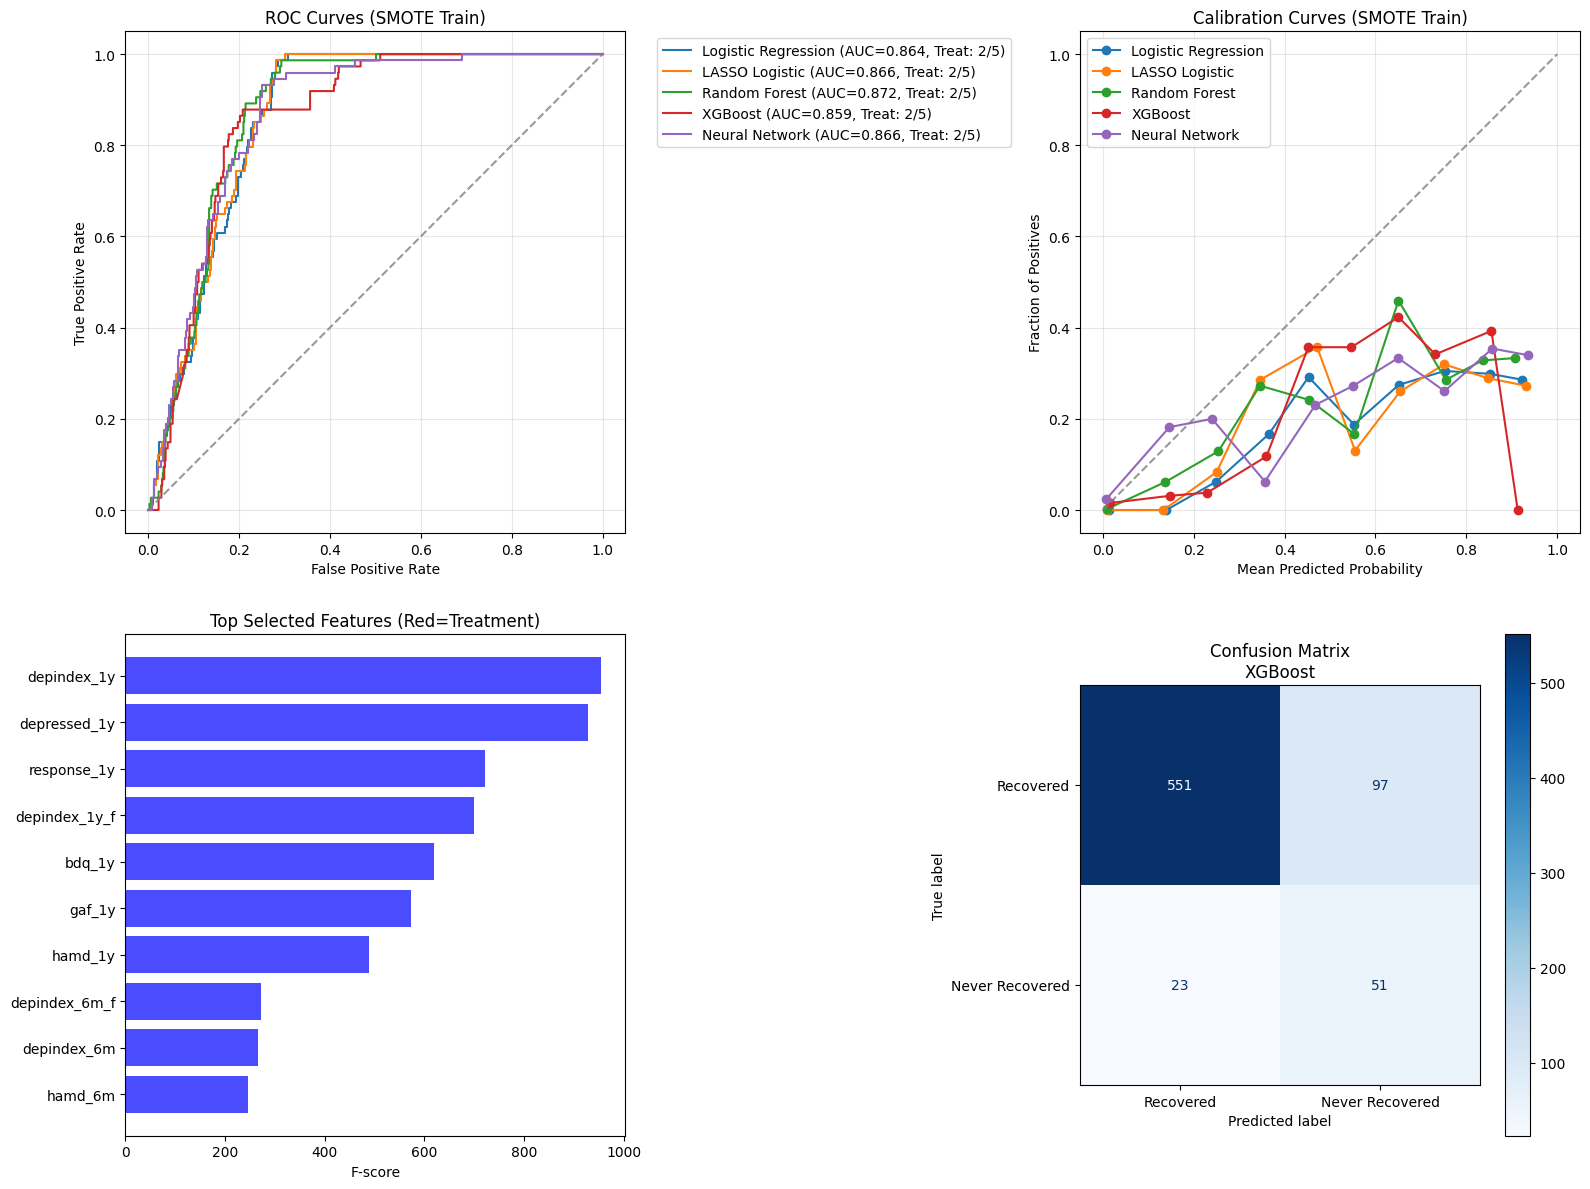

2025-07-10 09:05:18,975 - INFO - Refitted best: XGBoost
2025-07-10 09:05:19,081 - INFO - Calibration on train completed



Hold-out Performance:
Uncalibrated: AUC=0.835, F1=0.359
Calibrated:   AUC=0.844, F1=0.421


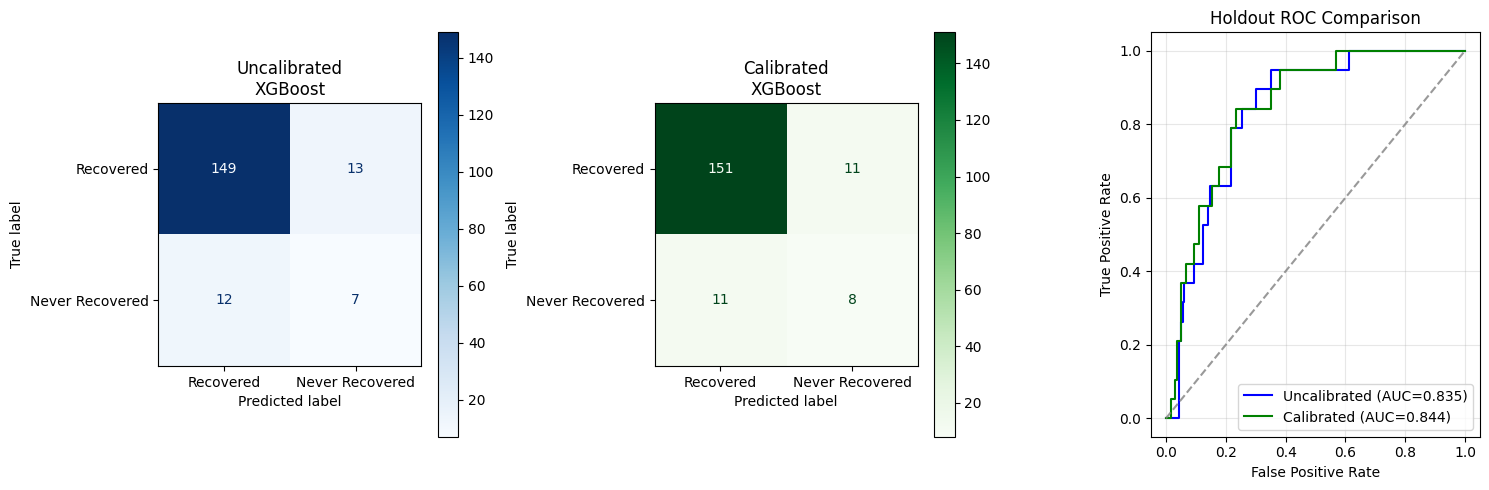

2025-07-10 09:05:19,351 - INFO - Performing SHAP analysis...
2025-07-10 09:05:19,352 - INFO - Treatment variable selected for SHAP: False



Detailed Holdout Metrics:
Metric          Uncalibrated Calibrated  
---------------------------------------
Accuracy        0.862        0.878       
Precision       0.350        0.421       
Recall          0.368        0.421       
F1 Score        0.359        0.421       
AUC             0.835        0.844       
Specificity     0.920        0.932       
Sensitivity     0.368        0.421       

Confusion Matrix Components:
Component       Uncalibrated Calibrated  
---------------------------------------
True Positives  7            8           
False Positives 13           11          
True Negatives  149          151         
False Negatives 12           11          


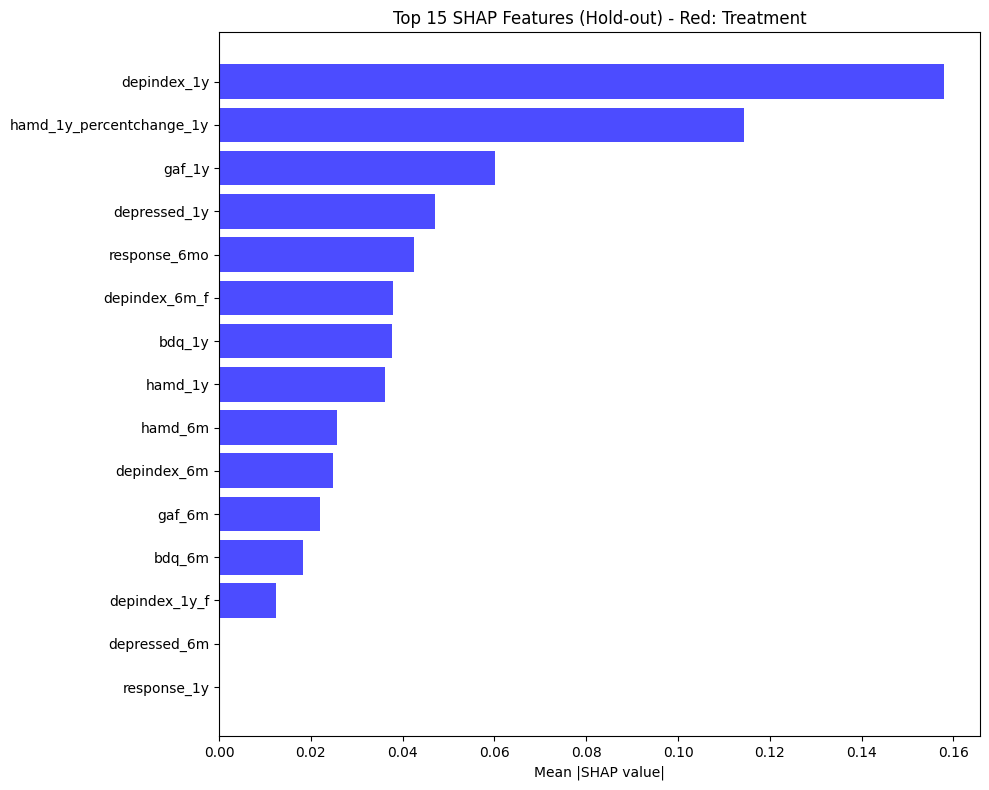

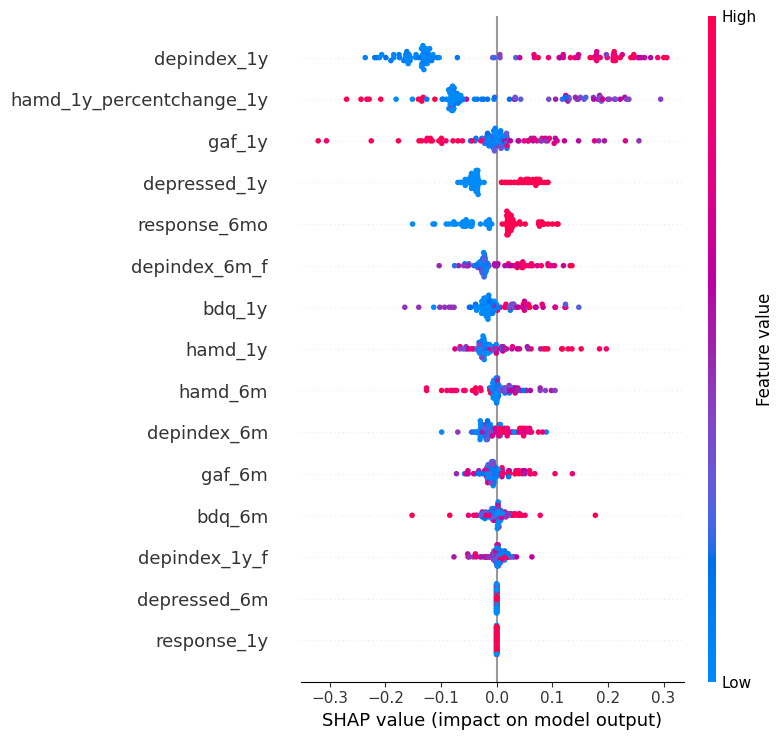


Generating SHAP Personas…
Top 3 SHAP features: ['gaf_1y', 'hamd_1y_percentchange_1y', 'depindex_1y']

Top-3 SHAP Personas:
                                                       Profile  P(never recover)
   gaf_1y=low & hamd_1y_percentchange_1y=low & depindex_1y=low             0.021
  gaf_1y=low & hamd_1y_percentchange_1y=low & depindex_1y=high             0.021
  gaf_1y=low & hamd_1y_percentchange_1y=high & depindex_1y=low             0.021
 gaf_1y=low & hamd_1y_percentchange_1y=high & depindex_1y=high             0.022
  gaf_1y=high & hamd_1y_percentchange_1y=low & depindex_1y=low             0.021
 gaf_1y=high & hamd_1y_percentchange_1y=low & depindex_1y=high             0.021
 gaf_1y=high & hamd_1y_percentchange_1y=high & depindex_1y=low             0.021
gaf_1y=high & hamd_1y_percentchange_1y=high & depindex_1y=high             0.021


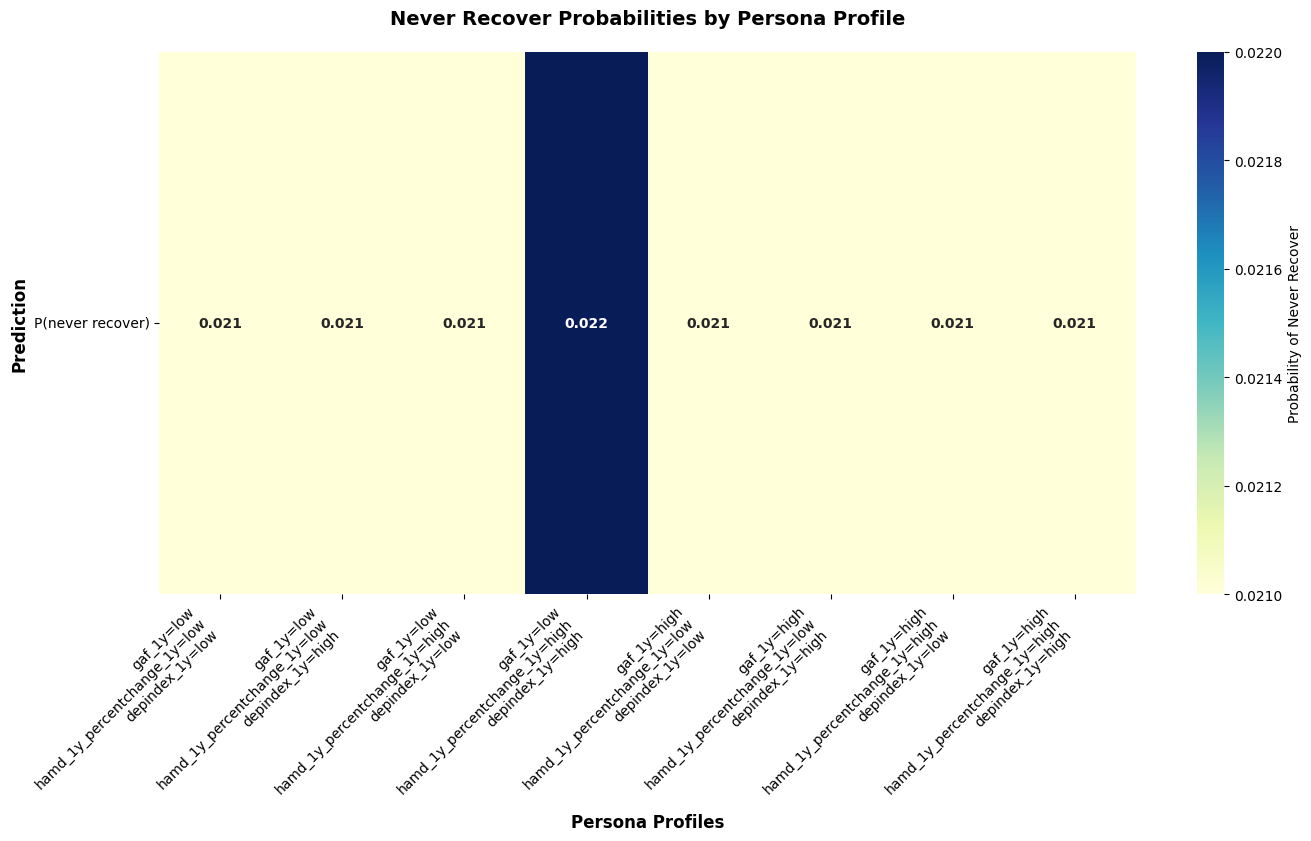

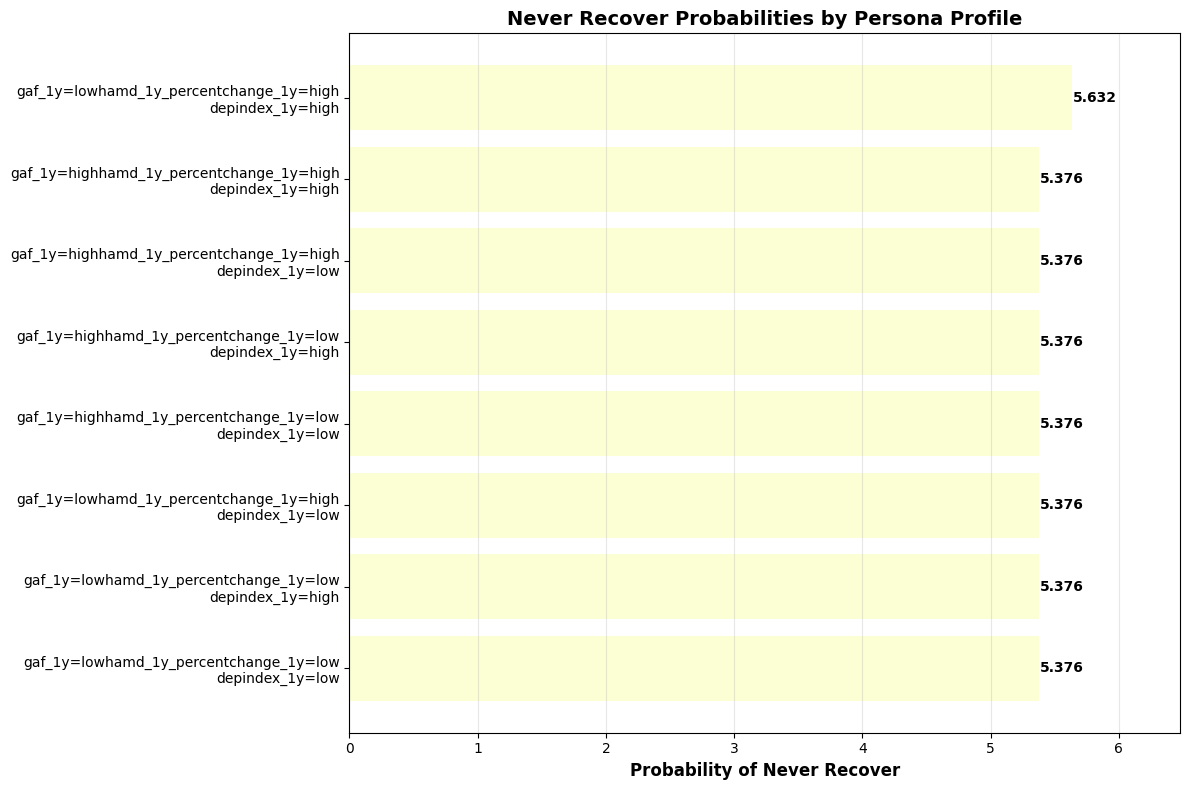


TREATMENT VARIABLE ANALYSIS
Logistic Regression:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
LASSO Logistic:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
Random Forest:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
XGBoost:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4
Neural Network:
  Treatment selected: 2/5 folds
  Average F-score: 127.452
  Average rank: 17.4

FINAL RESULTS SUMMARY
Best Model: XGBoost
Hold-out Performance (Calibrated):
  Accuracy: 0.878
  Precision: 0.421
  Recall: 0.421
  F1 Score: 0.421
  AUC: 0.844
  Brier Score: 0.103
  True Negatives: 151.000
  False Positives: 11.000
  False Negatives: 11.000
  True Positives: 8.000
  Specificity: 0.932
  Sensitivity: 0.421
⚠ Treatment variable was NOT selected by the best model
Overall treatment selection rate: 10/25 (40.0%)


In [72]:
# Never recovered at 7 years - Nested CV (FIXED VERSION)

# ========= Imports =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import tensorflow as tf 
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from skopt import BayesSearchCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from tabulate import tabulate
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ========= Configuration =========
@dataclass
class Config:
    RANDOM_STATE: int = 123
    N_FEATURES: int = 15
    OUTER_SPLITS: int = 5
    INNER_SPLITS: int = 3
    N_ITER: int = 20
    TEST_SIZE: float = 0.2
    TARGET_COL: str = "recover_never"
    ID_COL: str = "newid"
    EXCLUDE_COLS: List[str] = None
    
    def __post_init__(self):
        if self.EXCLUDE_COLS is None:
            self.EXCLUDE_COLS = ["recurrence_7y", "remission_1y", 
"remission_6mo", "recovery_1y"
    ]

config = Config()

# ========= Logging Setup =========
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ========= Data Validation =========
def validate_data(df: pd.DataFrame, target_col: str, required_cols: List[str]) -> None:
    """Validate input data quality"""
    assert not df.empty, "DataFrame is empty"
    assert target_col in df.columns, f"Target column '{target_col}' not found"
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    assert df[target_col].nunique() > 1, "Target has only one class"
    logger.info(f"Data validation passed. Shape: {df.shape}")

# ========= UPDATED: SMOTE Pipeline Builder =========
def build_smote_pipeline(base_model, config: Config, include_oversampling: bool = True):
    """
    Build a pipeline that uses SMOTE for oversampling instead of stratified approach
    """
    if include_oversampling:
        # Use imblearn pipeline with SMOTE
        pipeline = ImbPipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('oversample', SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    else:
        # Standard pipeline without oversampling
        pipeline = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('select', SelectKBest(score_func=f_classif, k=config.N_FEATURES)),
            ('model', base_model)
        ])
    
    return pipeline

# ========= UPDATED: Nested CV with SMOTE =========
def run_nested_cv_smote(model, param_distributions: Dict, X: pd.DataFrame, y: np.ndarray, 
                        config: Config, include_oversampling: bool = True) -> Dict[str, Any]:
    """
    Nested CV with SMOTE oversampling instead of stratified oversampling
    """
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=config.INNER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)

    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    outer_scores = []
    successful_folds = 0
    feature_importance_dicts = []
    treatment_selected_count = 0
    treatment_scores = []  # Track treatment F-scores

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing outer fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Log treatment and class distribution in this fold
            if 'treat' in X_train_fold.columns:
                treat_dist = X_train_fold['treat'].value_counts()
                logger.info(f"Fold {fold+1} treatment distribution: {treat_dist.to_dict()}")
            
            class_dist = pd.Series(y_train_fold).value_counts()
            logger.info(f"Fold {fold+1} class distribution: {class_dist.to_dict()}")

            # Build SMOTE pipeline
            pipe = build_smote_pipeline(model, config, include_oversampling)
            
            # Hyperparameter search on training fold
            search_space = {f'model__{k}': v for k, v in param_distributions.items()}
            
            search = BayesSearchCV(
                pipe,
                search_spaces=search_space,
                n_iter=config.N_ITER,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=1,
                random_state=config.RANDOM_STATE,
                error_score='raise'
            )
            
            search.fit(X_train_fold, y_train_fold)
            best_model = search.best_estimator_

            # Check if treatment was selected as a feature
            if hasattr(best_model, 'named_steps') and 'select' in best_model.named_steps:
                selector = best_model.named_steps['select']
                selected_features = X_train_fold.columns[selector.get_support()].tolist()
                feature_scores = dict(zip(X_train_fold.columns, selector.scores_))
                
                # Track treatment selection and scoring
                treat_selected = 'treat' in selected_features
                treat_score = feature_scores.get('treat', 0)
                treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
                
                if treat_selected:
                    treatment_selected_count += 1
                    logger.info(f"Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f}, rank={treat_rank})")
                else:
                    logger.info(f"Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank}/{len(feature_scores)})")
                
                treatment_scores.append({
                    'fold': fold + 1,
                    'treat_score': treat_score,
                    'treat_rank': treat_rank,
                    'treat_selected': treat_selected
                })
                
                # Store feature importance info
                feature_importance_dicts.append({
                    'fold': fold + 1,
                    'selected_features': selected_features,
                    'treatment_selected': treat_selected,
                    'feature_scores': feature_scores
                })

            # Make predictions on test fold
            prob = best_model.predict_proba(X_test_fold)[:, 1]
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            outer_scores.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
            logger.info(f"Fold {fold+1} AUC: {outer_scores[-1]:.3f}")
            
        except Exception as e:
            logger.error(f"Error in fold {fold + 1}: {e}")
            # For failed folds, use neutral predictions
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            outer_scores.append(0.5)

    # Validate results
    if successful_folds < config.OUTER_SPLITS // 2:
        raise RuntimeError(f"Too many folds failed: {successful_folds}/{config.OUTER_SPLITS}")

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    # Log treatment selection summary
    logger.info(f"Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": search.best_estimator_ if 'search' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(outer_scores),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores,
        "feature_importance_info": feature_importance_dicts
    }

# ========= UPDATED: Neural Network CV with SMOTE =========
def run_nn_cv_smote(X: pd.DataFrame, y: np.ndarray, config: Config) -> Dict[str, Any]:
    """Neural network CV with SMOTE oversampling"""
    outer_cv = StratifiedKFold(n_splits=config.OUTER_SPLITS, shuffle=True, 
                              random_state=config.RANDOM_STATE)
    y_preds = np.full_like(y, -1, dtype=float)
    y_probs = np.full_like(y, -1, dtype=float)
    aucs = []
    successful_folds = 0
    feature_names = X.columns.tolist()
    treatment_selected_count = 0
    treatment_scores = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        logger.info(f"Processing NN fold {fold + 1}/{config.OUTER_SPLITS}")
        
        try:
            # Split data first
            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y[train_idx].copy()
            X_test_fold = X.iloc[test_idx].copy()
            y_test_fold = y[test_idx].copy()

            # Apply preprocessing
            imputer = SimpleImputer(strategy='median')
            scaler = StandardScaler()
            
            X_train_imputed = imputer.fit_transform(X_train_fold)
            X_train_scaled = scaler.fit_transform(X_train_imputed)
            X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
            
            # Apply SMOTE oversampling
            smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
            X_train_df, y_train_fold = smote.fit_resample(X_train_df, y_train_fold)
            
            logger.info(f"NN Fold {fold+1}: After SMOTE - {len(X_train_df)} samples, "
                       f"class distribution: {np.bincount(y_train_fold)}")

            # Feature selection on SMOTE-processed training data
            selector = SelectKBest(score_func=f_classif, k=config.N_FEATURES)
            X_train_selected = selector.fit_transform(X_train_df.values, y_train_fold)
            
            # Check if treatment was selected
            selected_features = X_train_df.columns[selector.get_support()].tolist()
            feature_scores = dict(zip(X_train_df.columns, selector.scores_))
            
            treat_selected = 'treat' in selected_features
            treat_score = feature_scores.get('treat', 0)
            treat_rank = sorted(feature_scores.values(), reverse=True).index(treat_score) + 1 if 'treat' in feature_scores else len(feature_scores)
            
            if treat_selected:
                treatment_selected_count += 1
                logger.info(f"NN Fold {fold+1}: Treatment variable selected! (F-score={treat_score:.3f})")
            else:
                logger.info(f"NN Fold {fold+1}: Treatment NOT selected (F-score={treat_score:.3f}, rank={treat_rank})")
            
            treatment_scores.append({
                'fold': fold + 1,
                'treat_score': treat_score,
                'treat_rank': treat_rank,
                'treat_selected': treat_selected
            })
            
            # Build and train model
            model = build_nn_model(input_dim=X_train_selected.shape[1])
            
            # Compute class weights
            unique_classes = np.unique(y_train_fold)
            if len(unique_classes) > 1:
                cw_vals = compute_class_weight('balanced', classes=unique_classes, y=y_train_fold)
                class_weights = {i: w for i, w in enumerate(cw_vals)}
            else:
                class_weights = None
            
            batch_size = max(8, min(32, len(X_train_selected) // 4))
            
            history = model.fit(
                X_train_selected, y_train_fold,
                validation_split=0.2,
                epochs=100,
                batch_size=batch_size,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                class_weight=class_weights,
                verbose=0
            )

            # Transform test data and make predictions
            X_test_imputed = imputer.transform(X_test_fold)
            X_test_scaled = scaler.transform(X_test_imputed)
            X_test_selected = selector.transform(X_test_scaled)
            
            prob = model.predict(X_test_selected, verbose=0).ravel()
            pred = (prob > 0.5).astype(int)
            
            y_probs[test_idx] = prob
            y_preds[test_idx] = pred
            aucs.append(roc_auc_score(y_test_fold, prob))
            successful_folds += 1
            
        except Exception as e:
            logger.error(f"Error in NN fold {fold + 1}: {e}")
            y_probs[test_idx] = 0.5
            y_preds[test_idx] = np.random.choice([0, 1], size=len(test_idx))
            aucs.append(0.5)

    # Calculate metrics on valid predictions
    valid_mask = (y_preds >= 0) & (y_probs >= 0)
    if not np.any(valid_mask):
        raise RuntimeError("No valid NN predictions generated")
    
    y_valid = y[valid_mask]
    y_preds_valid = y_preds[valid_mask]
    y_probs_valid = y_probs[valid_mask]

    logger.info(f"NN: Treatment variable selected in {treatment_selected_count}/{successful_folds} folds")
    if treatment_scores:
        avg_treat_score = np.mean([t['treat_score'] for t in treatment_scores])
        avg_treat_rank = np.mean([t['treat_rank'] for t in treatment_scores])
        logger.info(f"NN: Average treatment F-score: {avg_treat_score:.3f}, average rank: {avg_treat_rank:.1f}")

    return {
        "model": model if 'model' in locals() else None,
        "metrics": {
            "Accuracy": accuracy_score(y_valid, y_preds_valid),
            "Precision": precision_score(y_valid, y_preds_valid, zero_division=0),
            "Recall": recall_score(y_valid, y_preds_valid, zero_division=0),
            "F1 Score": f1_score(y_valid, y_preds_valid, zero_division=0),
            "AUC": np.mean(aucs),
            "Brier Score": brier_score_loss(y_valid, y_probs_valid)
        },
        "y_preds": y_preds,
        "y_probs": y_probs,
        "successful_folds": successful_folds,
        "treatment_selected_count": treatment_selected_count,
        "treatment_scores": treatment_scores
    }

# ========= Leak-Free Preprocessor (Unchanged) =========
class LeakFreePreprocessor:
    """
    Preprocessing that prevents data leakage by fitting only on training folds
    """
    
    def __init__(self, config: Config):
        self.config = config
        self.imputer = None
        self.scaler = None
        self.label_encoder = None
        self.feature_names = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series) -> 'LeakFreePreprocessor':
        """Fit preprocessor components separately to allow proper CV"""
        self.feature_names = X.columns.tolist()
        
        # Fit components
        self.imputer = SimpleImputer(strategy='median')
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
        # Fit on training data
        X_imputed = self.imputer.fit_transform(X)
        self.scaler.fit(X_imputed)
        self.label_encoder.fit(y)
        
        logger.info(f"Preprocessor fitted on {X.shape[0]} samples, {X.shape[1]} features")
        return self
    
    def transform_features(self, X):
        """Transform features using fitted preprocessor"""
        if isinstance(X, pd.DataFrame):
            X_ordered = X.reindex(columns=self.feature_names, fill_value=np.nan)
            X_values = X_ordered.values
        else:
            X_values = X
            
        X_imputed = self.imputer.transform(X_values)
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled
    
    def transform_target(self, y: pd.Series) -> np.ndarray:
        """Transform target using fitted label encoder"""
        return self.label_encoder.transform(y)
    
    def get_feature_names(self) -> List[str]:
        """Get original feature names"""
        return self.feature_names.copy()

# ========= Neural Network Builder (Unchanged) =========
def build_nn_model(input_dim: int, neurons1: int = 64, neurons2: int = 32, 
                   dropout: float = 0.3, learning_rate: float = 1e-3) -> tf.keras.Model:
    """Build neural network with improved architecture"""
    model = Sequential([
        Dense(neurons1, activation='relu', input_dim=input_dim,
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

# ========= Utility Functions (Enhanced with Treatment Tracking) =========
def calculate_holdout_metrics(y_true: np.ndarray, y_pred: np.ndarray, 
                            y_proba: np.ndarray) -> Dict[str, float]:
    """Calculate comprehensive holdout metrics including confusion matrix components"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Extract confusion matrix components
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba),
        'Brier Score': brier_score_loss(y_true, y_proba),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
    }

def plot_performance_curves(results: Dict, y_true: np.ndarray, feature_names, title_suffix: str = ""):
    """Generate ROC, calibration curves, and confusion matrix with treatment selection info"""
    plt.figure(figsize=(16, 12))  # Adjusted size for 2x2 layout
    
    # ROC Curves (Top Left)
    plt.subplot(2, 2, 1)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fpr, tpr, _ = roc_curve(y_valid, probs_valid)
                    auc = roc_auc_score(y_valid, probs_valid)
                    
                    # Enhanced label with treatment selection info
                    treat_count = res.get('treatment_selected_count', 0)
                    total_folds = res.get('successful_folds', 0)
                    label = f"{name} (AUC={auc:.3f}, Treat: {treat_count}/{total_folds})"
                    
                    plt.plot(fpr, tpr, label=label)
                        
            except Exception as e:
                logger.warning(f"Error plotting ROC for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves {title_suffix}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Calibration Curves (Top Right)
    plt.subplot(2, 2, 2)
    for name, res in results.items():
        if res and 'y_probs' in res:
            try:
                valid_mask = res['y_probs'] >= 0
                if np.any(valid_mask):
                    y_valid = y_true[valid_mask]
                    probs_valid = res['y_probs'][valid_mask]
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        y_valid, probs_valid, n_bins=10
                    )
                    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)
            except Exception as e:
                logger.warning(f"Error plotting calibration for {name}: {e}")
    
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration Curves {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Feature Importance (Bottom Left)
    plt.subplot(2, 2, 3)
    best_model_name = max(results.keys(), key=lambda k: results[k]['metrics']['AUC'] 
                         if results[k] and 'metrics' in results[k] else 0)
    best_model = results[best_model_name]['model']
    
    if best_model and hasattr(best_model, 'named_steps'):
        try:
            selector = best_model.named_steps['select']
            scores = selector.scores_
            top_idx = np.argsort(scores)[-10:]
            top_feats = [feature_names[i] for i in top_idx]
            
            # Highlight treatment variable if selected
            colors = ['red' if feat == 'treat' else 'blue' for feat in top_feats]
            plt.barh(range(len(top_idx)), scores[top_idx], color=colors, alpha=0.7)
            
            plt.yticks(range(len(top_idx)), top_feats)
            plt.xlabel("F-score")
            plt.title("Top Selected Features (Red=Treatment)")
        except Exception:
            plt.text(0.5, 0.5, "Feature importance\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    # Confusion Matrix for Best Model (Bottom Right)
    plt.subplot(2, 2, 4)
    if best_model_name in results and results[best_model_name]:
        try:
            res = results[best_model_name]
            valid_mask = res['y_probs'] >= 0
            if np.any(valid_mask):
                y_valid = y_true[valid_mask]
                y_pred_valid = res['y_preds'][valid_mask]
                
                cm = confusion_matrix(y_valid, y_pred_valid)
                disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                            display_labels=['Recovered', 'Never Recovered'])
                disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
                plt.title(f"Confusion Matrix\n{best_model_name}")
        except Exception as e:
            logger.warning(f"Error plotting confusion matrix: {e}")
            plt.text(0.5, 0.5, "Confusion Matrix\nnot available", 
                    ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# ========= Holdout Confusion Matrix Function =========

def plot_holdout_confusion_matrices(y_true, preds_unc, preds_cal, probs_unc, probs_cal, best_name):
    """Plot confusion matrices for holdout predictions"""
    plt.figure(figsize=(15, 5))
    
    # Uncalibrated Confusion Matrix
    plt.subplot(1, 3, 1)
    cm_unc = confusion_matrix(y_true, preds_unc)
    disp_unc = ConfusionMatrixDisplay(confusion_matrix=cm_unc, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_unc.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f"Uncalibrated\n{best_name}")
    
    # Calibrated Confusion Matrix
    plt.subplot(1, 3, 2)
    cm_cal = confusion_matrix(y_true, preds_cal)
    disp_cal = ConfusionMatrixDisplay(confusion_matrix=cm_cal, 
                                     display_labels=['Recovered', 'Never Recovered'])
    disp_cal.plot(ax=plt.gca(), cmap='Greens', values_format='d')
    plt.title(f"Calibrated\n{best_name}")
    
    # ROC Comparison
    plt.subplot(1, 3, 3)
    fpr_unc, tpr_unc, _ = roc_curve(y_true, probs_unc)
    fpr_cal, tpr_cal, _ = roc_curve(y_true, probs_cal)
    
    auc_unc = roc_auc_score(y_true, probs_unc)
    auc_cal = roc_auc_score(y_true, probs_cal)
    
    plt.plot(fpr_unc, tpr_unc, label=f'Uncalibrated (AUC={auc_unc:.3f})', color='blue')
    plt.plot(fpr_cal, tpr_cal, label=f'Calibrated (AUC={auc_cal:.3f})', color='green')
    plt.plot([0,1],[0,1],'--',color='gray', alpha=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Holdout ROC Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def perform_shap_analysis(best_model, X_holdout: np.ndarray, feature_names: List[str],
                         preprocessor: LeakFreePreprocessor, holdout_raw: pd.DataFrame):
    """Perform SHAP analysis with proper error handling"""
    try:
        logger.info("Performing SHAP analysis...")
        
        model_obj = best_model.named_steps['model']
        if not hasattr(model_obj, 'predict_proba'):
            logger.warning("Model doesn't support probability prediction, skipping SHAP")
            return None
        
        selector = best_model.named_steps['select']
        X_selected = selector.transform(X_holdout)
        selected_feature_names = [feature_names[i] for i in selector.get_support(indices=True)]
        
        # Highlight if treatment is selected
        treat_selected = 'treat' in selected_feature_names
        logger.info(f"Treatment variable selected for SHAP: {treat_selected}")
        
        n_background = min(100, X_selected.shape[0])
        background_data = X_selected[:n_background]
        
        if hasattr(model_obj, 'tree_'):
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(background_data)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.Explainer(model_obj.predict_proba, background_data)
            shap_values = explainer(background_data)
            if hasattr(shap_values, 'values'):
                shap_values = shap_values.values[:, :, 1]
        
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_n = min(15, len(selected_feature_names))
        top_idx = np.argsort(shap_abs)[-top_n:]
        
        plt.figure(figsize=(10, 8))
        colors = ['red' if selected_feature_names[i] == 'treat' else 'blue' for i in top_idx]
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color=colors, alpha=0.7)
        plt.yticks(range(len(top_idx)), [selected_feature_names[i] for i in top_idx])
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"Top {top_n} SHAP Features (Hold-out) - Red: Treatment")
        plt.tight_layout()
        plt.show()
        
        try:
            shap.summary_plot(
                shap_values, 
                features=background_data, 
                feature_names=selected_feature_names,
                show=False
            )
            plt.tight_layout()
            plt.show()
        except Exception as e:
            logger.warning(f"Error creating SHAP summary plot: {e}")
            
    except Exception as e:
        logger.error(f"Error in SHAP analysis: {e}")
        return None

    return {
        'selector': selector,
        'shap_values': shap_values if 'shap_values' in locals() else None,
        'selected_feature_names': selected_feature_names if 'selected_feature_names' in locals() else []
    }

# ========= FIXED: Main Pipeline =========
def main():
    """FIXED: Main execution pipeline without data leakage"""

    # 1. Load & validate
    try:
        df = pd.read_csv("complete_data_mice_7y_never.csv")
        logger.info(f"Data loaded: {df.shape}")
        required = [config.TARGET_COL, config.ID_COL] + config.EXCLUDE_COLS + ['treat']
        validate_data(df, config.TARGET_COL, required)
    except Exception as e:
        logger.error(f"Loading/validation error: {e}")
        return

    # 2. Quick QC
    logger.info(f"Target counts:\n{df[config.TARGET_COL].value_counts()}")
    logger.info(f"Missing values: {df.isnull().sum().sum()}")

    # 3. CRITICAL: Train/hold-out split FIRST, before any processing
    train_df, holdout_df = train_test_split(
        df,
        test_size=config.TEST_SIZE,
        stratify=df[config.TARGET_COL],
        random_state=config.RANDOM_STATE
    )
    logger.info(f"Train={len(train_df)}, Hold-out={len(holdout_df)}")

    # 4. Prepare training data (keep as DataFrame to preserve column names)
    X_train = train_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    y_train = train_df[config.TARGET_COL].values
    feature_names = X_train.columns.tolist()

    # 5. Define models & parameters
    models_and_params = {
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.01, 0.1, 1.0, 10.0]}
        ),
        "LASSO Logistic": (
            LogisticRegression(penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced',
                               random_state=config.RANDOM_STATE),
            {"C": [0.001, 0.01, 0.1, 1, 10]}
        ),
        "Random Forest": (
            RandomForestClassifier(class_weight='balanced',
                                   random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "max_depth": [3, 5, 10],
             "min_samples_split": [5, 10],
             "min_samples_leaf": [2, 5]}
        ),
        "XGBoost": (
            XGBClassifier(use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=config.RANDOM_STATE),
            {"n_estimators": [50, 100],
             "learning_rate": [0.01, 0.1],
             "max_depth": [3, 6],
             "subsample": [0.8, 1.0]}
        )
    }

    # 6. Run nested CV with SMOTE (using the correct function names)
    results = {}
    for name, (model, params) in models_and_params.items():
        logger.info(f"→ Nested CV: {name}")
        try:
            results[name] = run_nested_cv_smote(
                model, params, X_train, y_train, config, include_oversampling=True
            )
            logger.info(f"   AUC={results[name]['metrics']['AUC']:.3f}")
        except Exception as e:
            logger.error(f"   {name} failed: {e}")

    # 7. Neural network with SMOTE
    try:
        logger.info("→ Nested CV: Neural Network")
        results['Neural Network'] = run_nn_cv_smote(X_train, y_train, config)
        logger.info(f"   AUC={results['Neural Network']['metrics']['AUC']:.3f}")
    except Exception as e:
        logger.error(f"   NN failed: {e}")

    # 8. Show performance table with treatment selection info
    perf_rows = []
    for m, res in results.items():
        if res and 'metrics' in res:
            row = {"Model": m}
            row.update({k: round(v, 3) for k, v in res['metrics'].items()})
            row["Folds"] = res.get('successful_folds', 'N/A')
            row["Treat_Selected"] = f"{res.get('treatment_selected_count', 0)}/{res.get('successful_folds', 0)}"
            perf_rows.append(row)
    perf_df = pd.DataFrame(perf_rows)
    print("\nNested CV Performance (with Treatment Selection)")
    print(tabulate(perf_df, headers='keys', tablefmt='grid', showindex=False))

    # 9. Fit preprocessor on full training data for final model preparation
    preprocessor = LeakFreePreprocessor(config)
    preprocessor.fit(X_train, train_df[config.TARGET_COL])
    
    # Transform training data
    X_train_proc = preprocessor.transform_features(X_train)
    X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
    y_train_processed = preprocessor.transform_target(train_df[config.TARGET_COL])
    
    # Apply SMOTE oversampling for final model training
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=3)
    X_train_final, y_res = smote.fit_resample(X_train_df, y_train_processed)
    logger.info(f"Final training data after SMOTE: {X_train_final.shape}, class distribution: {np.bincount(y_res)}")

    # 10. Plot OOF ROC + calibration
    plot_performance_curves(results, y_train, feature_names, title_suffix="(SMOTE Train)")

    # 11. Refit best pipeline on full SMOTE-resampled train data
    if not results:
        logger.error("No successful models to select from")
        return
        
    best_name = max(results, key=lambda k: results[k]['metrics']['AUC'] if results[k] else 0)
    best_result = results[best_name]
    
    if not best_result or 'model' not in best_result:
        logger.error(f"Best model {best_name} has no trained model")
        return
        
    # Build and fit new pipeline on full resampled data
    best_pipe = build_smote_pipeline(
        models_and_params[best_name][0], config, include_oversampling=False
    )
    best_pipe.fit(X_train_final, y_res)
    logger.info(f"Refitted best: {best_name}")

    # 12. Calibrate via Platt scaling
    X_sel_train = best_pipe.named_steps['select'].transform(X_train_final)
    calibrator = CalibratedClassifierCV(
        best_pipe.named_steps['model'],
        method='sigmoid',
        cv=3  # Use CV instead of prefit since we have enough data
    )
    calibrator.fit(X_sel_train, y_res)
    logger.info("Calibration on train completed")

    # 13. Prepare hold-out
    X_hold = holdout_df.drop(columns=[config.ID_COL, config.TARGET_COL] + config.EXCLUDE_COLS)
    X_hold_proc = preprocessor.transform_features(X_hold)  # (n_hold, n_feats)
    y_hold = preprocessor.transform_target(holdout_df[config.TARGET_COL])

    # 14a) uncalibrated on full pipeline:
    probs_unc = best_pipe.predict_proba(X_hold_proc)[:,1]

    # 14b) calibrated: first select, then calibrator
    selector = best_pipe.named_steps['select']
    X_hold_sel = selector.transform(X_hold_proc)  # (n_hold, k_features)
    probs_cal = calibrator.predict_proba(X_hold_sel)[:, 1]

    # 15) threshold & metrics
    preds_unc = (probs_unc > 0.5).astype(int)
    preds_cal = (probs_cal > 0.5).astype(int)
    hold_unc = calculate_holdout_metrics(y_hold, preds_unc, probs_unc)
    hold_cal = calculate_holdout_metrics(y_hold, preds_cal, probs_cal)
    
    print(f"\nHold-out Performance:")
    print(f"Uncalibrated: AUC={hold_unc['AUC']:.3f}, F1={hold_unc['F1 Score']:.3f}")
    print(f"Calibrated:   AUC={hold_cal['AUC']:.3f}, F1={hold_cal['F1 Score']:.3f}")

    # Plot holdout confusion matrices
    plot_holdout_confusion_matrices(y_hold, preds_unc, preds_cal, probs_unc, probs_cal, best_name)
    
    # Print detailed confusion matrix metrics
    print(f"\nDetailed Holdout Metrics:")
    print(f"{'Metric':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Specificity', 'Sensitivity']:
        print(f"{metric:<15} {hold_unc[metric]:<12.3f} {hold_cal[metric]:<12.3f}")
    
    print(f"\nConfusion Matrix Components:")
    print(f"{'Component':<15} {'Uncalibrated':<12} {'Calibrated':<12}")
    print(f"{'-'*39}")
    for component in ['True Positives', 'False Positives', 'True Negatives', 'False Negatives']:
        print(f"{component:<15} {hold_unc[component]:<12} {hold_cal[component]:<12}")
        
    # 16. SHAP + Personas
    shap_info = perform_shap_analysis(
    best_pipe,
    X_hold_proc,
    feature_names,
    preprocessor,
    holdout_df
)

    if shap_info and shap_info['shap_values'] is not None:
        selector_ = shap_info['selector']
        sv = shap_info['shap_values']
        feats = shap_info['selected_feature_names']
        abs_mean = np.abs(sv).mean(axis=0)
        
        if len(feats) >= 3:
            print("\nGenerating SHAP Personas…")
            raw_df = train_df.drop(columns=config.EXCLUDE_COLS + [config.ID_COL])
            raw_median = raw_df.median()
            raw_min = raw_df.min()
            raw_max = raw_df.max()
            
            # pick top-3 by |SHAP|
            top3_idx = np.argsort(abs_mean)[-3:]
            top3_feats = [feats[i] for i in top3_idx]
            
            print(f"Top 3 SHAP features: {top3_feats}")
            
            # Create a custom preprocessor-selector-calibrator pipeline for personas
            class PersonaPipeline:
                def __init__(self, preprocessor, selector, calibrator):
                    self.preprocessor = preprocessor
                    self.selector = selector
                    self.calibrator = calibrator
                
                def predict_proba(self, X_raw):
                    # Preprocess raw data
                    X_proc = self.preprocessor.transform_features(X_raw)
                    # Select features
                    X_sel = self.selector.transform(X_proc)
                    # Get calibrated probabilities
                    return self.calibrator.predict_proba(X_sel)
            
            final_pipe = PersonaPipeline(preprocessor, selector_, calibrator)
            
            prototypes = []
            for combo in product(['low','high'], repeat=3):
                row = raw_median.copy()
                desc = []
                for feat, lvl in zip(top3_feats, combo):
                    row[feat] = raw_min[feat] if lvl=='low' else raw_max[feat]
                    desc.append(f"{feat}={lvl}")
                
                # Create DataFrame with correct column order matching feature_names
                arr_df = pd.DataFrame([row.reindex(feature_names)])
                try:
                    p = final_pipe.predict_proba(arr_df)[0,1]
                    prototypes.append({
                        'Profile': ' & '.join(desc),
                        'P(never recover)': round(p, 3)
                    })
                except Exception as e:
                    logger.warning(f"Error generating persona for {desc}: {e}")
            
            if prototypes:
                proto_df = pd.DataFrame(prototypes)
                print("\nTop-3 SHAP Personas:")
                print(proto_df.to_string(index=False))
                
                try:
                    # Create figure with larger size to accommodate labels
                    plt.figure(figsize=(14, 8))
                    
                    # Function to format long labels with line breaks
                    def format_label(label, max_chars_per_line=30):
                        """Break long labels into multiple lines"""
                        parts = label.split(' & ')
                        formatted_parts = []
                        current_line = ""
                        
                        for part in parts:
                            if len(current_line + part) <= max_chars_per_line:
                                current_line += part + " & " if current_line else part
                            else:
                                if current_line:
                                    formatted_parts.append(current_line.rstrip(" & "))
                                current_line = part + " & "
                        
                        if current_line:
                            formatted_parts.append(current_line.rstrip(" & "))
                        
                        return '\n'.join(formatted_parts)
                    
                    # Format the profile labels
                    formatted_labels = [format_label(profile) for profile in proto_df['Profile']]
                    
                    # Create the heatmap with formatted labels
                    heatmap_data = proto_df.set_index('Profile')[['P(never recover)']].T
                    heatmap_data.columns = formatted_labels
                    
                    ax = sns.heatmap(
                        heatmap_data,
                        annot=True, 
                        cmap='YlGnBu', 
                        fmt='.3f',
                        cbar_kws={'label': 'Probability of Never Recover'},
                        annot_kws={'size': 10, 'weight': 'bold'}
                    )
                    
                    # Rotate x-axis labels for better readability
                    plt.xticks(rotation=45, ha='right')
                    plt.yticks(rotation=0)
                    
                    # Adjust layout and titles
                    plt.title("Never Recover Probabilities by Persona Profile", 
                            fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel("Persona Profiles", fontsize=12, fontweight='bold')
                    plt.ylabel("Prediction", fontsize=12, fontweight='bold')
                    
                    # Adjust layout to prevent label cutoff
                    plt.tight_layout()
                    plt.subplots_adjust(bottom=0.25)  # Add extra space at bottom for labels
                    
                    plt.show()
                    
                    # Alternative: Create a horizontal bar chart for better label visibility
                    plt.figure(figsize=(12, 8))
                    
                    # Sort by probability for better visualization
                    sorted_df = proto_df.sort_values('P(never recover)', ascending=True)
                    formatted_labels_sorted = [format_label(profile, max_chars_per_line=50) 
                                            for profile in sorted_df['Profile']]
                    
                    bars = plt.barh(range(len(sorted_df)), sorted_df['P(never recover)'], 
                                color=plt.cm.YlGnBu(sorted_df['P(never recover)']))
                    
                    # Add value labels on bars
                    for i, (bar, prob) in enumerate(zip(bars, sorted_df['P(never recover)'])):
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                                f'{prob:.3f}', va='center', fontweight='bold')
                    
                    plt.yticks(range(len(sorted_df)), formatted_labels_sorted)
                    plt.xlabel('Probability of Never Recover', fontsize=12, fontweight='bold')
                    plt.title('Never Recover Probabilities by Persona Profile', 
                            fontsize=14, fontweight='bold')
                    plt.grid(axis='x', alpha=0.3)
                    
                    # Set x-axis limits for better visibility
                    plt.xlim(0, max(sorted_df['P(never recover)']) * 1.15)
                    
                    plt.tight_layout()
                    plt.show()
                    
                except Exception as e:
                    logger.warning(f"Error creating persona visualizations: {e}")
    else:
        logger.warning("SHAP analysis failed or returned no results. Skipping persona generation.")

    # 17. Treatment analysis summary
    print(f"\n{'='*60}")
    print("TREATMENT VARIABLE ANALYSIS")
    print(f"{'='*60}")
    
    for model_name, result in results.items():
        if result and 'treatment_scores' in result:
            treat_count = result.get('treatment_selected_count', 0)
            total_folds = result.get('successful_folds', 0)
            treat_scores = result.get('treatment_scores', [])
            
            if treat_scores:
                avg_score = np.mean([t['treat_score'] for t in treat_scores])
                avg_rank = np.mean([t['treat_rank'] for t in treat_scores])
                print(f"{model_name}:")
                print(f"  Treatment selected: {treat_count}/{total_folds} folds")
                print(f"  Average F-score: {avg_score:.3f}")
                print(f"  Average rank: {avg_rank:.1f}")
    
    # 18. Final summary
    print(f"\n{'='*60}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"Best Model: {best_name}")
    print(f"Hold-out Performance (Calibrated):")
    for metric, value in hold_cal.items():
        print(f"  {metric}: {value:.3f}")
    
    # Check if treatment was selected in best model
    if shap_info and 'selected_feature_names' in shap_info and 'treat' in shap_info['selected_feature_names']:
        print("✓ Treatment variable was selected by the best model")
    else:
        print("⚠ Treatment variable was NOT selected by the best model")
    
    # Overall treatment selection rate
    total_treat_selections = sum(r.get('treatment_selected_count', 0) for r in results.values() if r)
    total_folds = sum(r.get('successful_folds', 0) for r in results.values() if r)
    if total_folds > 0:
        overall_rate = total_treat_selections / total_folds
        print(f"Overall treatment selection rate: {total_treat_selections}/{total_folds} ({overall_rate:.1%})")
    
    print(f"{'='*60}")

if __name__ == "__main__":
    main()